In [2]:
from plot_functions2 import *

### Combined simulations

In [11]:
#============================================================================================================================
# All Plots for Grid simulations
#============================================================================================================================
complete_sims_dict = {}

fig_path = 'C:/Users/micae/OneDrive/Documents/MASTERS/Figures/20M_Grid_complete'
file1 = 'plot'
file2 = 'plot2'

mass_ratios = np.arange(0.1, 0.99, 0.1)
periods = np.arange(0.2, 1.55, 0.1)
for mass_ratio in mass_ratios:
    for period in periods:
        
        path = f'E:/Temp_sims/20M_grid/A20-{mass_ratio:.1f}-{period:.1f}/' 
        ext_path = f'E:/Temp_sims/20M_Grid_ext_combined/A20-{mass_ratio:.1f}-{period:.1f}/' 
        final_ext_path = f'E:/Temp_sims/20M_Grid_ext_final_combined/A20-{mass_ratio:.1f}-{period:.1f}/' 
        savepath = f'{fig_path}/{mass_ratio:.1f}_mass_ratio/A20-{mass_ratio:.1f}-{period:.1f}/'
        
        if not os.path.isdir(final_ext_path) or not os.path.isfile(os.path.join(final_ext_path, "plot")):
            continue
        name = f'A20-{mass_ratio:.1f}-{period:.1f}'
        print('\n')
        print('='*30)
        print(name)
        print('='*30, '\n')

        star1, star2 = readin_binary_data(path, file1, file2, single_star=False, print_summary=True)
        star_ext, star_ext_th = readin_binary_data(ext_path, file1, file2, single_star=False, print_summary=False)
        star_ext_final, star_1M = readin_binary_data(final_ext_path, file1, file2, single_star=False, print_summary=False)

        res1, H1, He1, temp1, psi1 = get_final_out(star1, star2, path, savepath, 'primary', save=False)
        res2, H2, He2, temp2, psi2 = get_final_out(star1, star2, path, savepath, 'secondary', save=False)
        
        out_star1 = (res1, H1, He1, temp1, psi1)
        out_star2 = (res2, H2, He2, temp2, psi2)
        
        binary_res, data_to_write = determine_binary_result(out_star1, out_star2)

        res1_ext, H1_ext, He1_ext, temp1_ext, psi1_ext = get_final_out(star_ext, star_ext_th, ext_path, savepath, 'primary', save=False)
        res2_ext, H2_ext, He2_ext, temp2_ext, psi2_ext = get_final_out(star_ext, star_ext_th, ext_path, savepath, 'secondary', save=False)
        
        res_final, _, _, _, _ = get_final_out(star_ext_final, star_1M, final_ext_path, savepath, 'primary', save=False)

        if res_final !=0:
            print('Final sim PASS')

            if binary_res > 10:
                # System is reversed
                print('REVERSE')

                if res2_ext == 0 and res1_ext != 0:
                    # Thermohaline mixing EXTENDS lifetime
                    print('TH LONGER')
                    exts = [star_ext]
                    th_exts = [star_ext_th, star_ext_final]
                    
                    star1_complete, star2_complete = combine_simulations(star1, star2, exts, star_to_add_ext=1)
                    star1_complete_th, _ = combine_simulations(star1, star2, th_exts, star_to_add_ext=1)
    
                else:
                    # Thermohaline mixing SHORTENS lifetime (normal)
                    print('TH SHORTER')
                    exts = [star_ext, star_ext_final]
                    th_exts = [star_ext_th]
                    
                    star1_complete, star2_complete = combine_simulations(star1, star2, exts, star_to_add_ext=1)
                    star1_complete_th, _ = combine_simulations(star1, star2, th_exts, star_to_add_ext=1)

                temp_dict = {
                    'rev': True,
                    'star1': star1_complete,
                    'star2': star2_complete,
                    'star_th': star1_complete_th
                }
                print(temp_dict)
                
                complete_sims_dict[name]= temp_dict
                # make_all_plots(path, star1_complete, star2_complete, savepath, th_comparison=True, star_th=star1_complete_th, 
                #                reverse=True, save_figures=True)
                # thermohaline_lifetime_comparison(star1_complete, star1_complete_th, savepath)

                # print(star1)
                # plt.plot(star2_complete[0])
                # plt.show()
                # plt.plot(star1_complete[0])
                # plt.show()
                # plt.plot(star1_complete_th[0])
                # plt.show()

                # print('Lifetime')
                # plt.plot(star2_complete[1])
                # plt.show()
                # plt.plot(star1_complete[1])
                # plt.show()
                # plt.plot(star1_complete_th[1])
                # plt.show()

            else:
                # System NOT reversed
                print('STANDARD')

                if res2_ext == 0 and res1_ext != 0:
                    # Thermohaline mixing EXTENDS lifetime
                    print('TH LONGER')
                    exts = [star_ext]
                    th_exts = [star_ext_th, star_ext_final]
                    
                    star1_complete, star2_complete = combine_simulations(star1, star2, exts, star_to_add_ext=2)
                    _, star2_complete_th = combine_simulations(star1, star2, th_exts, star_to_add_ext=2)
    
                else:
                    # Thermohaline mixing SHORTENS lifetime (normal)
                    print('TH SHORTER')
                    exts = [star_ext, star_ext_final]
                    th_exts = [star_ext_th]
                    
                    star1_complete, star2_complete = combine_simulations(star1, star2, exts, star_to_add_ext=2)
                    _, star2_complete_th = combine_simulations(star1, star2, th_exts, star_to_add_ext=2)

                temp_dict = {
                    'rev': False,
                    'star1': star1_complete,
                    'star2': star2_complete,
                    'star_th': star2_complete_th
                }
                print(temp_dict)
                
                complete_sims_dict[name]= temp_dict
                # make_all_plots(path, star1_complete, star2_complete, savepath, th_comparison=True, star_th=star2_complete_th, 
                #                reverse=False, save_figures=True)
                # thermohaline_lifetime_comparison(star2_complete, star2_complete_th, savepath)
                
                # print(star1)
                # plt.plot(star1_complete[0])
                # plt.show()
                # plt.plot(star2_complete[0])
                # plt.show()
                # plt.plot(star2_complete_th[0])
                # plt.show()
                
                # print('Lifetime')
                # plt.plot(star1_complete[1])
                # plt.show()
                # plt.plot(star2_complete[1])
                # plt.show()
                # plt.plot(star2_complete_th[1])
                # plt.show()
            
            
            
        else:
            print('Final sim FAILED')
            

    # combine_folder_pdfs(f"{fig_path}/{mass_ratio:.1f}_mass_ratio", f"{fig_path}/MR_{mass_ratio:.1f}_complete_analysis.pdf")



A20-0.1-0.5

This system initially has a 20.0M star and a 2.0M star, with an orbital period of 3.162 days. 

Final sim FAILED


A20-0.1-0.6

This system initially has a 20.0M star and a 2.0M star, with an orbital period of 3.981 days. 

Final sim PASS
STANDARD
TH SHORTER
{'rev': False, 'star1':           0             1        2        3        4         5        6   \
0          0  0.000000e+00  0.86513  4.48530  4.62470  20.00000  0.00001   
1          1  7.500000e+04  0.77132  4.53764  4.64642  19.99720  0.00002   
2          2  8.100000e+04  0.76754  4.53896  4.64417  19.99697  0.00002   
3          3  8.181005e+04  0.76738  4.53886  4.64343  19.99694  0.00002   
4          4  8.278211e+04  0.76680  4.53908  4.64318  19.99690  0.00002   
...      ...           ...      ...      ...      ...       ...      ...   
11618  11618  1.142314e+07  0.75862  4.58396  4.80634   3.27370  0.00000   
11619  11619  1.142314e+07  0.75871  4.58392  4.80635   3.27370  0.00000   
11620  11620  1.14

In [16]:
# import pickle
filename = 'complete_sims_files.pkl'

#Save sims
with open(filename, 'wb') as f:
    # 3. Use pickle.dump to save the dictionary to the file
    pickle.dump(complete_sims_dict, f)

print(f"Dictionary successfully saved to {filename}")

Dictionary successfully saved to complete_sims_files.pkl


### Full Composition graphs

In [3]:
import pickle

filename = 'complete_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    complete_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(complete_sims_dict))   # should be <class 'dict'>
print(complete_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A20-0.1-0.6', 'A20-0.1-0.7', 'A20-0.1-0.8', 'A20-0.1-0.9', 'A20-0.1-1.0', 'A20-0.1-1.1', 'A20-0.1-1.2', 'A20-0.1-1.3', 'A20-0.1-1.4', 'A20-0.1-1.5', 'A20-0.2-0.5', 'A20-0.2-0.6', 'A20-0.2-0.7', 'A20-0.2-0.8', 'A20-0.2-0.9', 'A20-0.2-1.0', 'A20-0.2-1.1', 'A20-0.2-1.2', 'A20-0.2-1.3', 'A20-0.2-1.4', 'A20-0.2-1.5', 'A20-0.3-0.2', 'A20-0.3-0.3', 'A20-0.3-0.4', 'A20-0.3-0.5', 'A20-0.3-0.6', 'A20-0.3-0.7', 'A20-0.3-0.8', 'A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.3', 'A20-0.4-0.4', 'A20-0.4-0.5', 'A20-0.4-0.6', 'A20-0.4-0.7', 'A20-0.4-0.8', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5-0.3', 'A20-0.5-0.4', 'A20-0.5-0.5', 'A20-0.5-0.6', 'A20-0.5-0.7', 'A20-0.5-0.8', 'A20-0.5-0.9', 'A20-0.5-1.1', 'A20-0.5-1.2', 'A20-0.5-1.3', 'A20-0.5-1.4', 'A20-0.6-0.3', 'A20-0.6-0.4', 'A20-0.6-0.5', 'A20-0.6-0.7', 'A20-0.6-0.9

In [ ]:
# Setup
fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid_Complete'
file1 = 'out'
file2 = 'out2'

# Configurations
text_size = 16
mass_ratios = [0.1, 0.9]
periods = [0.6, 1.2]

for mass_ratio in mass_ratios:
    for period in periods:
        
        # Path definitions
        path = f'/media/micaelas/Expansion/Temp_sims/20M_grid/A20-{mass_ratio:.1f}-{period:.1f}/' 
        ext_path = f'/media/micaelas/Expansion/Temp_sims/20M_Grid_ext_combined/A20-{mass_ratio:.1f}-{period:.1f}/' 
        final_ext_path = f'/media/micaelas/Expansion/Temp_sims/20M_Grid_ext_final_combined/A20-{mass_ratio:.1f}-{period:.1f}/' 
        savepath = f'{fig_path}/{mass_ratio:.1f}_mass_ratio/A20-{mass_ratio:.1f}-{period:.1f}/'
        
        # Check files exist
        if not os.path.isdir(final_ext_path) or not os.path.isfile(os.path.join(final_ext_path, "plot")):
            continue
            
        name = f'A20-{mass_ratio:.1f}-{period:.1f}'
        print('\n')
        print('='*30)
        print(name)
        print('='*30, '\n')

        # Retrieve Star Objects
        star2 = complete_sims_dict[name]['star2']
        star2_th = complete_sims_dict[name]['star_th']

        # Call the plotting function
        plot_he_composition_grid(
            star2=star2,
            star2_th=star2_th,
            path=path,
            ext_path=ext_path,
            final_ext_path=final_ext_path,
            file1=file1,
            file2=file2,
            mass_ratio=mass_ratio,
            savepath=savepath,
            text_size=text_size,
            save_fig=True,    # Set to False to disable saving
            print_info=False  # Set to True to see print statements
        )

### Surface vs Central Composition Graphs

In [3]:
import pickle

filename = 'complete_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    complete_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(complete_sims_dict))   # should be <class 'dict'>
print(complete_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A20-0.1-0.6', 'A20-0.1-0.7', 'A20-0.1-0.8', 'A20-0.1-0.9', 'A20-0.1-1.0', 'A20-0.1-1.1', 'A20-0.1-1.2', 'A20-0.1-1.3', 'A20-0.1-1.4', 'A20-0.1-1.5', 'A20-0.2-0.5', 'A20-0.2-0.6', 'A20-0.2-0.7', 'A20-0.2-0.8', 'A20-0.2-0.9', 'A20-0.2-1.0', 'A20-0.2-1.1', 'A20-0.2-1.2', 'A20-0.2-1.3', 'A20-0.2-1.4', 'A20-0.2-1.5', 'A20-0.3-0.2', 'A20-0.3-0.3', 'A20-0.3-0.4', 'A20-0.3-0.5', 'A20-0.3-0.6', 'A20-0.3-0.7', 'A20-0.3-0.8', 'A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.3', 'A20-0.4-0.4', 'A20-0.4-0.5', 'A20-0.4-0.6', 'A20-0.4-0.7', 'A20-0.4-0.8', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5-0.3', 'A20-0.5-0.4', 'A20-0.5-0.5', 'A20-0.5-0.6', 'A20-0.5-0.7', 'A20-0.5-0.8', 'A20-0.5-0.9', 'A20-0.5-1.1', 'A20-0.5-1.2', 'A20-0.5-1.3', 'A20-0.5-1.4', 'A20-0.6-0.3', 'A20-0.6-0.4', 'A20-0.6-0.5', 'A20-0.6-0.7', 'A20-0.6-0.9

In [4]:
A20_09_08 = complete_sims_dict['A20-0.9-0.8']
A20_05_08 = complete_sims_dict['A20-0.5-0.8']
A20_01_08 = complete_sims_dict['A20-0.1-0.8']

In [5]:
def get_out_summary_concentration_models(path, savepath, star_type, element, location):
    """
    Prints out the final output model from the STARS code out file.
    Inputs:
        path = a string of the path to the file (NOT including the file)
        savepath = a string of the path to the save location
        star_type = either 'primary' or 'secondary'. This determines which file from the folder is used (out for the primary or out2 for the secondary)
    Outputs:
        result = a flag indicating whether the simulation passed  or failed
        H_core = concentration of H at the center of the star
        He_core = concentration of He at the center of the star
        temp_core = temperature at the center of the star
    """
    
    last_match_buffer = []  # Stores the last match and its lines
    print_next = 0          # Countdown for how many lines to collect
    collecting = False      # Flag to indicate we're collecting after a match
    timesteps = []          # Initialise timestep array
    concentrations = []     # Initialise concentrations array
    
    if star_type in ['Primary', 'primary', '1', 1]:
        full_path = f'{path}out'
        type_path = ''
        title = 'Final output for primary star:'
    elif star_type in ['Secondary', 'secondary', '2', 2]:
        full_path = f'{path}out2'
        type_path = '2'
        title = 'Final output for secondary star:'
    else:
        print('ERROR: star_type invalid, please choose \'primary\' or \'secondary\'.')
        return

    if element == 'H1':
        element_idx = 6
    elif element == 'He4':
        element_idx = 7
    elif element == 'C12':
        element_idx = 8
    elif element == 'N14':
        element_idx = 9
    elif element == 'O16':
        element_idx = 10
    elif element == 'Ne20':
        element_idx = 11
    elif element == 'He3':
        element_idx = 12
    else:
        print('ERROR: element invalid, please choose one of: \'H1\', \'He4\', \'C12\', \'N14\', \'O16\', \'Ne20\', \'He3\'.')
        return

    if location == 'cntr':
        lines_after = 2
    elif location =='srfc':
        lines_after = 3
    elif location == 'Tmax':
        lines_after = 4
    else:
        print('ERROR: location invalid, please choose one of: \'cntr\', \'srfc\', \'Tmax\'.')
        return
    
    phrases = ['dt/age/MH/MHe']

    number_pattern = r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+(?:[eE][-+]?\d+)?'

    with open(full_path, 'r', encoding='utf-8') as out:

        for line in out:
            # Check for matches
            if any(phrase in line for phrase in phrases):
                temp_buffer = []            # Temporary buffer to collect lines after a match
                print_next = lines_after    # Reset counter
                collecting = True           # Start collecting

            # If there is a match, collect the lines, otherwise move on to the next
            if collecting:
                temp_buffer.append(line)
                print_next -= 1
                if print_next == 0:
                    collecting = False

                    first_line_numbers = re.findall(number_pattern, temp_buffer[0])
                    current_timestep =  int(first_line_numbers[0])
                    timesteps.append(current_timestep)

                    last_line_numbers = re.findall(number_pattern, temp_buffer[-1])
                    current_concentration =  float(last_line_numbers[element_idx])
                    concentrations.append(current_concentration)

    return np.array(timesteps), np.array(concentrations)

In [ ]:
# A20-0.1-0.8
path = '/media/micaelas/Expansion/Temp_sims/20M_grid/A20-0.1-0.8/'
ext_path = '/media/micaelas/Expansion/Temp_sims/20M_Grid_ext_combined/A20-0.1-0.8/' 
final_ext_path = '/media/micaelas/Expansion/Temp_sims/20M_Grid_ext_final_combined/A20-0.1-0.8/' 

fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid_Complete'
savepath = f'{fig_path}/0.1_mass_ratio/A20-0.1-0.8/'

# first sim
timesteps1, central_He_conc1 = get_out_summary_concentration_models(path, savepath, star_type='secondary', element='He4', location='cntr')
timesteps1, surface_He_conc1 = get_out_summary_concentration_models(path, savepath, star_type='secondary', element='He4', location='srfc')

# second sim
timesteps2, central_He_conc2 = get_out_summary_concentration_models(ext_path, savepath, star_type='primary', element='He4', location='cntr')
timesteps2, surface_He_conc2 = get_out_summary_concentration_models(ext_path, savepath, star_type='primary', element='He4', location='srfc')

timesteps2_th, central_He_conc2_th = get_out_summary_concentration_models(ext_path, savepath, star_type='secondary', element='He4', location='cntr')
timesteps2_th, surface_He_conc2_th = get_out_summary_concentration_models(ext_path, savepath, star_type='secondary', element='He4', location='srfc')

# third sim
timesteps3, central_He_conc3 = get_out_summary_concentration_models(final_ext_path, savepath, star_type='primary', element='He4', location='cntr')
timesteps3, surface_He_conc3 = get_out_summary_concentration_models(final_ext_path, savepath, star_type='primary', element='He4', location='srfc')

# timestep correction (because I was silly)
correction = 7490
print(correction)
timesteps2 = timesteps2 + correction
timesteps2_th = timesteps2_th + correction
timesteps3 = timesteps3 + correction

# combine the sims into one
star2_timesteps = np.concatenate([timesteps1, timesteps2, timesteps3])
star2_central_He_conc = np.concatenate([central_He_conc1, central_He_conc2, central_He_conc3])
star2_surface_He_conc = np.concatenate([surface_He_conc1, surface_He_conc2, surface_He_conc3])

star2_th_timesteps = np.concatenate([timesteps1, timesteps2_th])
star2_th_central_He_conc = np.concatenate([central_He_conc1, central_He_conc2_th])
star2_th_surface_He_conc = np.concatenate([surface_He_conc1, surface_He_conc2_th])

# clear out extras
data_star2 = pd.DataFrame({'timesteps': star2_timesteps, 'central_He_conc': star2_central_He_conc, 'surface_He_conc': star2_surface_He_conc})
data_star2 = data_star2.drop_duplicates(subset='timesteps', keep='last').sort_values('timesteps').reset_index(drop=True)

data_star2_th = pd.DataFrame({'timesteps': star2_th_timesteps, 'central_He_conc': star2_th_central_He_conc, 'surface_He_conc': star2_th_surface_He_conc})
data_star2_th = data_star2_th.drop_duplicates(subset='timesteps', keep='last').sort_values('timesteps').reset_index(drop=True)

# Get end of main sequence:
eoMS = find_helium_flash_timestep(A20_01_08['star2'], plot_figure=False)
eoMS_th = find_helium_flash_timestep(A20_01_08['star_th'], plot_figure=False)


# muted_colors = sns.color_palette("muted")

# plt.plot(data_star2['timesteps'], data_star2['central_He_conc'], color=muted_colors[0], label='Central He Concentration')
# plt.plot(data_star2['timesteps'], data_star2['surface_He_conc'], color=muted_colors[1], label='Surface He Concentration')
# ymin, ymax = plt.ylim()
# plt.vlines(x=eoMS, ymin=ymin, ymax=ymax, linestyles='--', color='grey', label='End of Main Sequence')
# plt.ylim(ymin, ymax)
# plt.legend()
# plt.show()

# plt.plot(data_star2_th['timesteps'], data_star2_th['central_He_conc'], color=muted_colors[0], label='Central He Concentration')
# plt.plot(data_star2_th['timesteps'], data_star2_th['surface_He_conc'], color=muted_colors[1], label='Surface He Concentration')
# ymin, ymax = plt.ylim()
# plt.vlines(x=eoMS_th, ymin=ymin, ymax=ymax, linestyles='--', color='grey', label='End of Main Sequence')
# plt.ylim(ymin, ymax)
# plt.legend()
# plt.show()

muted_colors = sns.color_palette("muted")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# No thermohaline mixing
ax1.plot(data_star2['timesteps'], data_star2['central_He_conc'],
         color=muted_colors[0], label='Central He Concentration')
ax1.plot(data_star2['timesteps'], data_star2['surface_He_conc'],
         color=muted_colors[1], label='Surface He Concentration')

ymin, ymax = ax1.get_ylim()
ax1.vlines(x=eoMS, ymin=ymin, ymax=ymax, linestyles='--', color='grey', label='End of Main Sequence')
ax1.set_ylim(ymin, ymax)

ax1.set_xlabel('Timesteps')
ax1.set_ylabel('He Concentration')
ax1.set_title('No Thermohaline Mixing')
ax1.legend()

# thermohaline mixing
ax2.plot(data_star2_th['timesteps'], data_star2_th['central_He_conc'],
         color=muted_colors[0], label='Central He Concentration')
ax2.plot(data_star2_th['timesteps'], data_star2_th['surface_He_conc'],
         color=muted_colors[1], label='Surface He Concentration')

ymin, ymax = ax2.get_ylim()
ax2.vlines(x=eoMS_th, ymin=ymin, ymax=ymax, linestyles='--', color='grey', label='End of Main Sequence')
ax2.set_ylim(ymin, ymax)

ax2.set_xlabel('Timesteps')
ax2.set_title('With Thermohaline Mixing')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{savepath}/surface_vs_central_He_th_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

### Mass range

In [3]:
import pickle

filename = 'initial_20M_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    M20_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(M20_sims_dict))   # should be <class 'dict'>
print(M20_sims_dict.keys())


# filename = 'complete_sims_files.pkl'

# # Load the dictionary
# with open(filename, 'rb') as f:
#     complete_sims_dict = pickle.load(f)

# print("Dictionary successfully loaded!")
# print(type(complete_sims_dict))   # should be <class 'dict'>
# print(complete_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A20-0.1-0.2', 'A20-0.1-0.4', 'A20-0.1-0.5', 'A20-0.1-0.6', 'A20-0.1-0.7', 'A20-0.1-0.8', 'A20-0.1-0.9', 'A20-0.1-1.0', 'A20-0.1-1.1', 'A20-0.1-1.2', 'A20-0.1-1.3', 'A20-0.1-1.4', 'A20-0.1-1.5', 'A20-0.2-0.2', 'A20-0.2-0.3', 'A20-0.2-0.4', 'A20-0.2-0.5', 'A20-0.2-0.6', 'A20-0.2-0.7', 'A20-0.2-0.8', 'A20-0.2-0.9', 'A20-0.2-1.0', 'A20-0.2-1.1', 'A20-0.2-1.2', 'A20-0.2-1.3', 'A20-0.2-1.4', 'A20-0.2-1.5', 'A20-0.3-0.2', 'A20-0.3-0.3', 'A20-0.3-0.4', 'A20-0.3-0.5', 'A20-0.3-0.6', 'A20-0.3-0.7', 'A20-0.3-0.8', 'A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.2', 'A20-0.4-0.3', 'A20-0.4-0.4', 'A20-0.4-0.5', 'A20-0.4-0.6', 'A20-0.4-0.7', 'A20-0.4-0.8', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.2', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5-0.2', 'A20-0.5-0.3', 'A20-0.5-0.4', 'A20-0.5-0.5', 'A20-0.5-0.6', 'A20-0.5-0.7', 'A20-0.5-0.8', 'A20-0.5-0.9

In [4]:
filename = 'initial_10M_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    M10_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(M10_sims_dict))   # should be <class 'dict'>
print(M10_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A10-0.1-0.3', 'A10-0.1-0.4', 'A10-0.1-0.5', 'A10-0.1-0.6', 'A10-0.1-0.7', 'A10-0.1-0.8', 'A10-0.1-0.9', 'A10-0.1-1.0', 'A10-0.1-1.1', 'A10-0.1-1.2', 'A10-0.1-1.3', 'A10-0.1-1.4', 'A10-0.1-1.5', 'A10-0.2-0.2', 'A10-0.2-0.3', 'A10-0.2-0.4', 'A10-0.2-0.5', 'A10-0.2-0.6', 'A10-0.2-0.7', 'A10-0.2-0.8', 'A10-0.2-0.9', 'A10-0.2-1.0', 'A10-0.2-1.1', 'A10-0.2-1.2', 'A10-0.2-1.3', 'A10-0.2-1.4', 'A10-0.2-1.5', 'A10-0.3-0.2', 'A10-0.3-0.3', 'A10-0.3-0.4', 'A10-0.3-0.5', 'A10-0.3-0.6', 'A10-0.3-0.7', 'A10-0.3-0.8', 'A10-0.3-0.9', 'A10-0.3-1.0', 'A10-0.3-1.1', 'A10-0.3-1.2', 'A10-0.3-1.3', 'A10-0.3-1.4', 'A10-0.3-1.5', 'A10-0.4-0.2', 'A10-0.4-0.3', 'A10-0.4-0.4', 'A10-0.4-0.5', 'A10-0.4-0.6', 'A10-0.4-0.7', 'A10-0.4-0.8', 'A10-0.4-0.9', 'A10-0.4-1.0', 'A10-0.4-1.1', 'A10-0.4-1.2', 'A10-0.4-1.3', 'A10-0.4-1.4', 'A10-0.4-1.5', 'A10-0.5-0.2', 'A10-0.5-0.3', 'A10-0.5-0.4', 'A10-0.5-0.5', 'A10-0.5-0.6', 'A10-0.5-0.7', 'A10-0.5-0.8', 'A10-0.5-0.9

In [5]:
filename = 'initial_32M_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    M32_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(M32_sims_dict))   # should be <class 'dict'>
print(M32_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A32-0.1-0.2', 'A32-0.1-0.3', 'A32-0.1-0.4', 'A32-0.1-0.5', 'A32-0.1-0.6', 'A32-0.1-0.7', 'A32-0.1-0.8', 'A32-0.1-0.9', 'A32-0.1-1.0', 'A32-0.1-1.1', 'A32-0.1-1.2', 'A32-0.1-1.3', 'A32-0.1-1.4', 'A32-0.1-1.5', 'A32-0.2-0.2', 'A32-0.2-0.3', 'A32-0.2-0.4', 'A32-0.2-0.5', 'A32-0.2-0.6', 'A32-0.2-0.7', 'A32-0.2-0.8', 'A32-0.2-0.9', 'A32-0.2-1.0', 'A32-0.2-1.1', 'A32-0.2-1.2', 'A32-0.2-1.3', 'A32-0.2-1.4', 'A32-0.2-1.5', 'A32-0.3-0.2', 'A32-0.3-0.3', 'A32-0.3-0.4', 'A32-0.3-0.5', 'A32-0.3-0.6', 'A32-0.3-0.7', 'A32-0.3-0.8', 'A32-0.3-0.9', 'A32-0.3-1.0', 'A32-0.3-1.1', 'A32-0.3-1.2', 'A32-0.3-1.3', 'A32-0.3-1.4', 'A32-0.3-1.5', 'A32-0.4-0.2', 'A32-0.4-0.3', 'A32-0.4-0.4', 'A32-0.4-0.5', 'A32-0.4-0.6', 'A32-0.4-0.7', 'A32-0.4-0.8', 'A32-0.4-0.9', 'A32-0.4-1.0', 'A32-0.4-1.1', 'A32-0.4-1.2', 'A32-0.4-1.3', 'A32-0.4-1.4', 'A32-0.4-1.5', 'A32-0.5-0.2', 'A32-0.5-0.3', 'A32-0.5-0.4', 'A32-0.5-0.5', 'A32-0.5-0.6', 'A32-0.5-0.7', 'A32-0.5-0.8

In [12]:
max_binary_mass = max_prim_mass = 0
min_binary_mass = min_prim_mass = 1000

fails = ['A20-0.1-0.3', 'A20-0.7-0.2', 'A20-0.9-0.2', 'A20-0.6-0.2', 'A20-0.1-0.2']

for sim_key in M20_sims_dict.keys():
    if sim_key not in fails:
        star1 = M20_sims_dict[sim_key]['star1']
        star2 = M20_sims_dict[sim_key]['star2']
    
        high_binary_mass = np.max(star1[37])
        low_binary_mass = np.min(star1[37])

        if high_binary_mass > max_binary_mass:
            max_binary_mass = high_binary_mass
            
        if low_binary_mass < min_binary_mass:
            min_binary_mass = low_binary_mass


        apparent_prims = np.maximum(star1[5], star2[5])

        high_prim = np.max(apparent_prims)
        low_prim = np.min(apparent_prims) 
        arglow = np.argmin(apparent_prims)

        if high_prim > max_prim_mass:
            max_prim_mass = high_prim

        if low_prim < min_prim_mass:
            min_prim_mass = low_prim
            print(sim_key, arglow)

            

        
    # else:
        # print(sim_key)

print(f'Max binary mass: {max_binary_mass} \nMin binary mass: {min_binary_mass}')
print(f'Max primary mass: {max_prim_mass} \nMin primary mass: {min_prim_mass}')

A20-0.1-0.4 6110
A20-0.1-0.5 7160
A20-0.1-0.6 6324
A20-0.1-0.7 7771
A20-0.1-0.9 9135
Max binary mass: 38.0 
Min binary mass: 7.54151
Max primary mass: 30.50083 
Min primary mass: 5.02759


### Check and make plots

In [3]:
#============================================================================================================================
# Pass/Fail Check Only (currently final ext 199)
#============================================================================================================================

fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/New_sims/'
file1 = 'plot'
file2 = 'plot2'

mass_ratios = np.arange(0.1, 0.99, 0.1)
periods = np.arange(0.2, 1.55, 0.1)
for mass_ratio in mass_ratios:
    for period in periods:

        path = f'/media/micaelas/Expansion/Temp_sims/New_sims/stage_2/A20-{mass_ratio:.1f}-{period:.1f}/'
        savepath = f'{fig_path}/{mass_ratio:.1f}_mass_ratio/A20-{mass_ratio:.1f}-{period:.1f}/'
        
        if not os.path.isdir(path) or not os.path.isfile(os.path.join(path, "plot")):
            continue  # Skip if directory doesn't exist
            
        print(f'A20-{mass_ratio:.1f}-{period:.1f}\n')

        star1, star2 = readin_binary_data(path, file1, file2, single_star=False, print_summary=True)

        res1, H1, He1, temp1, psi1 = get_final_out(star1, star2, path, savepath, 'primary')
        res2, H2, He2, temp2, psi2 = get_final_out(star1, star2, path, savepath, 'secondary')
        
        out_star1 = (res1, H1, He1, temp1, psi1)
        out_star2 = (res2, H2, He2, temp2, psi2)
        
        final_res, data_to_write = determine_binary_result(out_star1, out_star2)
        write_pass_fail_file(final_res, *data_to_write, savepath)


    # combine_folder_pdfs(fig_path, f"{fig_path}/MR_{mass_ratio:.1f}_brief_analysis.pdf")

A20-0.1-0.5

This system initially has a 11.3M star and a 1.0M star, with an orbital period of 1e+78 days. 

Final output for the primary star: 
   69580  dt/age/MH/MHe  tn/tKH/Mb  P/rlf/dM LH/LHe/LC Lth/Lnu/m  H1      He4     C12     N14     O16     Ne20    He3       psi    dens    temp
  6.4585 4.357317913E-01 5.261E+05 2.732E+78 8.940E+04-2.001E+04-0.00000 0.11282 0.47641 0.00000 0.38629 0.02070 0.00000  -3.757  3.1263  8.3506  cntr
  6.0443 2.105987662E+07 3.946E+03-1.161E+02 6.232E+04 5.609E+03 0.32847 0.65201 0.00013 0.01252 0.00110 0.00199 0.00000 -20.619 -9.3946  3.7803  srfc
  0.0002  0.1111  1.8596    7.4585-3.660E-06 5.175E-17    0.0002-0.00000 0.11282 0.47641 0.00000 0.38629 0.02070 0.00000  -3.757  3.1263  8.3506  Tmax
  0.0000   3.502  -3.462   6.448  -6.448  -6.449   6.449   6.453  -6.453  -6.454   6.454   6.455  -6.455 -0.1416  0.0002  2.9131  2.5160  5.1063 69580
 352 499     417    -417     222    -220    -216     214     137    -137     -86      84      58     -57
  

Scanning simulation folders in: /home/micaelas/OneDrive/Documents/MASTERS/Figures/New_sims


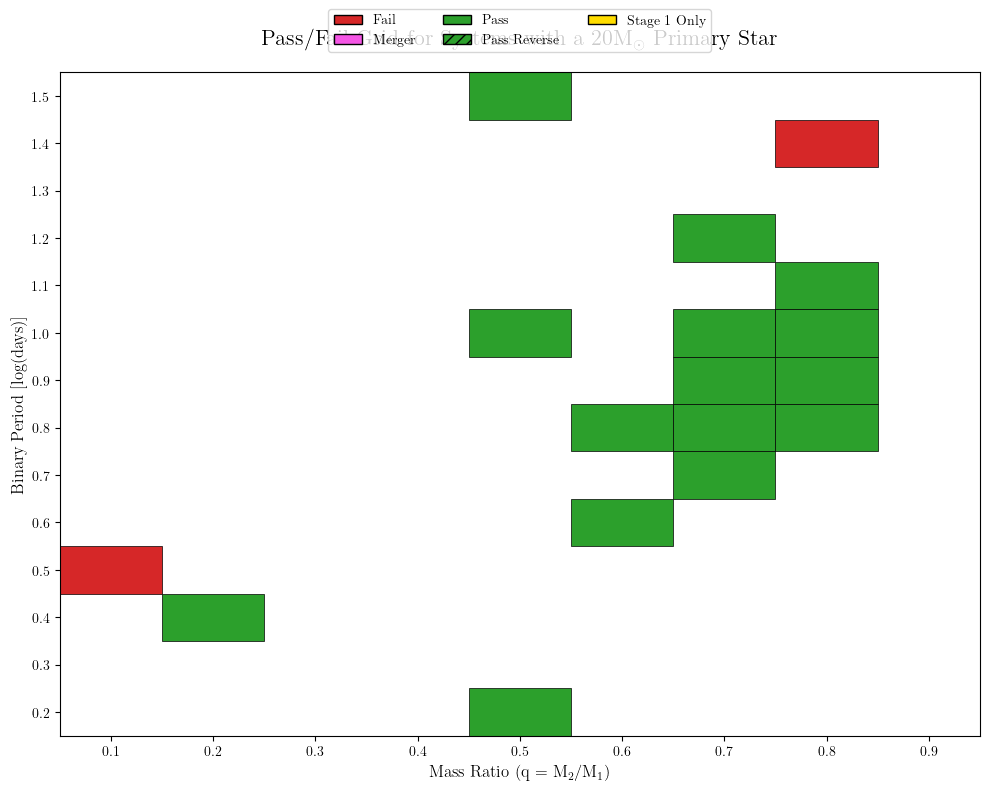

Grid completed!


In [4]:
#============================================================================================================================
# Create pass/fail grid
#============================================================================================================================
savepath = path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/New_sims'
create_simulation_grid(path, savepath, save_figure=False)

### Contact and Semi-Detached Location Graph

In [3]:
def plot_secondary_paths_on_period_MR_space(simulation_dict, sim_keys_to_plot, savepath, fig_filename='Contact_semidettached_graph.pdf', save_figure=True):
    """Makes a plot like it says"""

    plt.figure(figsize=(20,8))
    muted_colors = sns.color_palette("muted")
    cb_colors = sns.color_palette("colorblind")
    
    i = 0
    for sim_key in sim_keys_to_plot:
        # print(sim_key)
    
        # Check if system is reversed
        rev = simulation_dict[sim_key]['rev']
        merger = simulation_dict[sim_key]['merger']
        
        # Get out star1 and star2 plot data
        star1 = simulation_dict[sim_key]['star1']
        star2 = simulation_dict[sim_key]['star2']

        Prim_mass = star1.iloc[0,5]
        
        # # Get mass ratio
        # q_all = star2[5] / star1[5]
        # q = q_all[:len(star1[5])] # Cut the array to get rid of NaN values
        
        if rev:
            # print('Reversed')
            log_P = np.log10(star2[35])
            cross_colour = 'purple'
            plot_title = f'Contact and Semi-detached Phases for Reversed Systems with {Prim_mass:.0f} ' + r'M$_\odot$ Primaries'

        elif merger:
            # print('Reversed')
            log_P = np.log10(star1[35])
            cross_colour = '#e848a8'
            plot_title = f'Contact and Semi-detached Phases for Systems with {Prim_mass:.0f} ' + r'M$_\odot$ Primaries'
            
        else:
            log_P = np.log10(star1[35])
            cross_colour = 'red'
            plot_title = f'Contact and Semi-detached Phases for Systems with {Prim_mass:.0f} ' + r'M$_\odot$ Primaries'
    
    
        # Extract important information
        binarysep = star1[36] #Binary Separation
        radius1 = 10**star1[2] # Star radii
        radius2 = 10**star2[2]
        dM1 = star1[5]
        dM2 = star2[5]
    
        # Cut out extended simulation data
        binarysep = binarysep[:len(log_P)]
        radius1, radius2 = radius1[:len(log_P)], radius2[:len(log_P)]
        dM1, dM2 = dM1[:len(log_P)], dM2[:len(log_P)]
    
        # Calculate Roche radii
        q_inv = dM1/dM2 #The mass ratio
        q = dM2/dM1
        roche1 = binarysep * ((0.49 * q_inv**(2/3)) / (0.6 * q_inv**(2/3) + np.log(1 + q_inv**(1/3)))) #Effective Roche Lobe
        roche2 = binarysep * ((0.49 * q**(2/3)) / (0.6 * q**(2/3) + np.log(1 + q**(1/3))))
    
        # Check if roche lobes are filled
        rlof1 = radius1 - roche1
        rlof1_mask = rlof1 >= 0
        rlof2 = radius2 - roche2
        rlof2_mask = rlof2 >= 0
    
        # Create masks for contact and overflow phases
        contact_phase_mask = rlof1_mask * rlof2_mask
        
        overflow_occurs_mask = rlof1_mask ^ rlof2_mask
        overflow_only_star1_mask = overflow_occurs_mask & rlof1_mask
        overflow_only_star2_mask = overflow_occurs_mask & rlof2_mask
    
        combined_mask = contact_phase_mask | overflow_only_star1_mask | overflow_only_star2_mask
        no_overflow_mask = ~combined_mask
     
    
        q_true_array = np.array(q, dtype=float)
        q_array = np.where(q_true_array > 1, 1 / q_true_array, q_true_array)
        
        
        log_P_array = np.array(log_P, dtype=float)
        
        q_detached = q_array.copy()
        q_detached[~no_overflow_mask] = np.nan
        
        q_contact = q_array.copy()
        q_contact[~contact_phase_mask] = np.nan
        
        q_rlof1 = q_array.copy()
        q_rlof1[~overflow_only_star1_mask] = np.nan
        
        q_rlof2 = q_array.copy()
        q_rlof2[~overflow_only_star2_mask] = np.nan
        
        log_P_detached = log_P_array.copy()
        log_P_detached[~no_overflow_mask] = np.nan
        
        log_P_contact = log_P_array.copy()
        log_P_contact[~contact_phase_mask] = np.nan
        
        log_P_rlof1 = log_P_array.copy()
        log_P_rlof1[~overflow_only_star1_mask] = np.nan
        
        log_P_rlof2 = log_P_array.copy()
        log_P_rlof2[~overflow_only_star2_mask] = np.nan
    
    
    
        if i == 0:
            plt.plot(q_detached, log_P_detached, c='grey', label='Detached', lw=3, alpha=0.8)
            plt.plot(q_contact, log_P_contact, label='Contact', linestyle='--', c=cb_colors[0], lw=3, alpha=0.8)
            plt.plot(q_rlof1, log_P_rlof1, label='Semidetached (primary in RLOF)', c=cb_colors[1], lw=3, alpha=0.8)
            plt.plot(q_rlof2, log_P_rlof2, label='Semidetached (secondary in RLOF)', c=cb_colors[2], lw=3, alpha=0.8)
            
            
            plt.scatter(q_array[0], log_P_array[0], marker='+', s=100, c=cross_colour, label='Starting point', zorder=5, lw=2)
            plt.scatter(q_array[-1], log_P_array[-1], marker='x', s=80, c=cross_colour, label='Ending point', zorder=5, lw=2)
        else:
            plt.plot(q_detached, log_P_detached, c='grey', lw=3, alpha=0.8)
            plt.plot(q_contact, log_P_contact, linestyle='--', c=cb_colors[0], lw=3, alpha=0.8)
            plt.plot(q_rlof1, log_P_rlof1, c=cb_colors[1], lw=3, alpha=0.8)
            plt.plot(q_rlof2, log_P_rlof2, c=cb_colors[2], lw=3, alpha=0.8)
            plt.scatter(q_array[0], log_P_array[0], marker='+', s=100, c=cross_colour, zorder=5, lw=2)
            plt.scatter(q_array[-1], log_P_array[-1], marker='x', s=80, c=cross_colour, zorder=5, lw=2)
    
        
    
        i += 1
    
    # plt.ylim(0, 4.5)
    # plt.xlim(0, 1.1)
    # plt.xticks(np.arange(0, 3.65, 0.2))
    plt.xlabel(r'Apparent Mass Ratio q [$M_i$/$M_j$]')
    plt.ylabel('Log Period [log(days)]')
    plt.grid(alpha=0.4)
    plt.legend(framealpha=0.5, loc='upper right')
    plt.title(plot_title)
    if save_figure:
        plt.savefig(f'{savepath}/{fig_filename}', dpi=200, bbox_inches='tight')
    plt.show()
    

#### 10M Grid

In [4]:
filename = 'initial_10M_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    initial_10M_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(initial_10M_sims_dict))   # should be <class 'dict'>
print(initial_10M_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A10-0.1-0.3', 'A10-0.1-0.4', 'A10-0.1-0.5', 'A10-0.1-0.6', 'A10-0.1-0.7', 'A10-0.1-0.8', 'A10-0.1-0.9', 'A10-0.1-1.0', 'A10-0.1-1.1', 'A10-0.1-1.2', 'A10-0.1-1.3', 'A10-0.1-1.4', 'A10-0.1-1.5', 'A10-0.2-0.2', 'A10-0.2-0.3', 'A10-0.2-0.4', 'A10-0.2-0.5', 'A10-0.2-0.6', 'A10-0.2-0.7', 'A10-0.2-0.8', 'A10-0.2-0.9', 'A10-0.2-1.0', 'A10-0.2-1.1', 'A10-0.2-1.2', 'A10-0.2-1.3', 'A10-0.2-1.4', 'A10-0.2-1.5', 'A10-0.3-0.2', 'A10-0.3-0.3', 'A10-0.3-0.4', 'A10-0.3-0.5', 'A10-0.3-0.6', 'A10-0.3-0.7', 'A10-0.3-0.8', 'A10-0.3-0.9', 'A10-0.3-1.0', 'A10-0.3-1.1', 'A10-0.3-1.2', 'A10-0.3-1.3', 'A10-0.3-1.4', 'A10-0.3-1.5', 'A10-0.4-0.2', 'A10-0.4-0.3', 'A10-0.4-0.4', 'A10-0.4-0.5', 'A10-0.4-0.6', 'A10-0.4-0.7', 'A10-0.4-0.8', 'A10-0.4-0.9', 'A10-0.4-1.0', 'A10-0.4-1.1', 'A10-0.4-1.2', 'A10-0.4-1.3', 'A10-0.4-1.4', 'A10-0.4-1.5', 'A10-0.5-0.2', 'A10-0.5-0.3', 'A10-0.5-0.4', 'A10-0.5-0.5', 'A10-0.5-0.6', 'A10-0.5-0.7', 'A10-0.5-0.8', 'A10-0.5-0.9

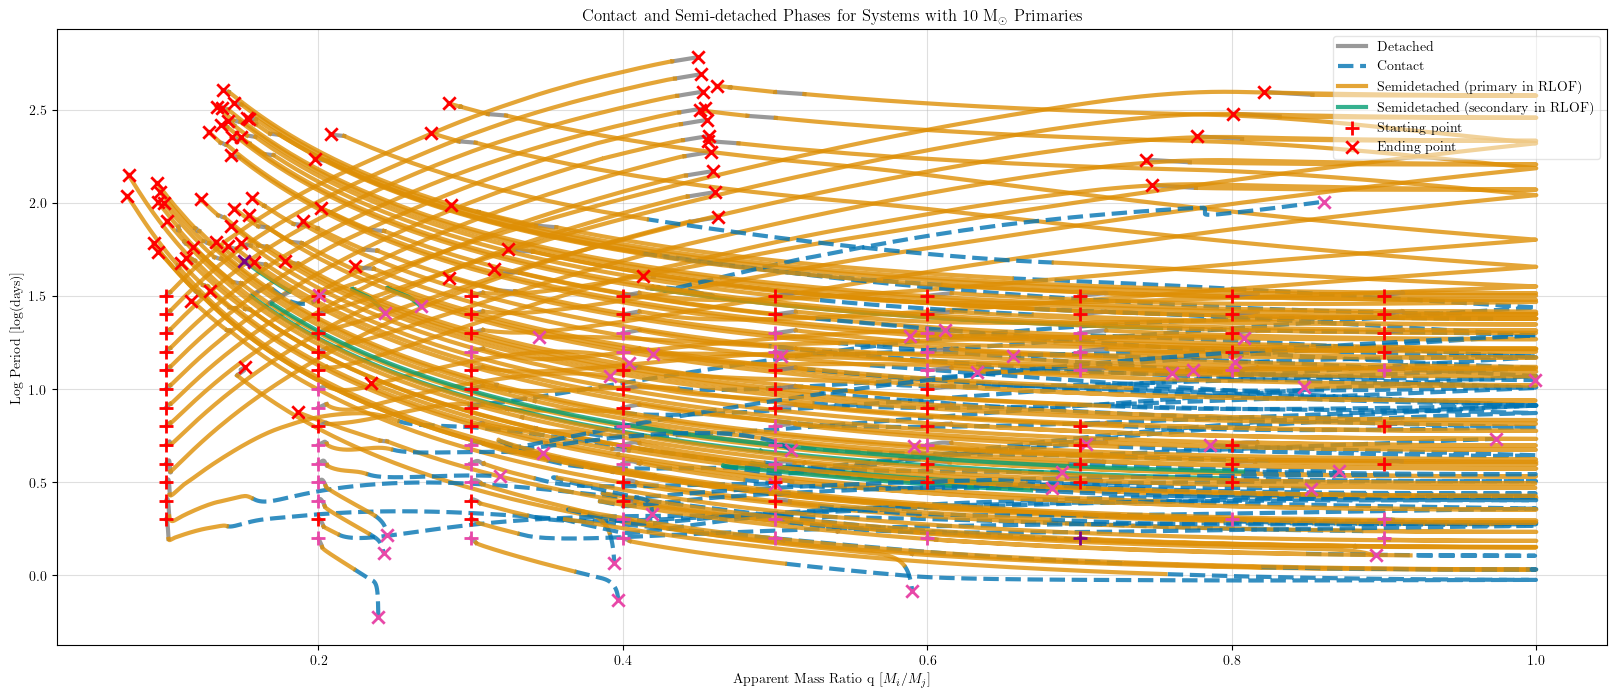

In [5]:
all_10M_sims = initial_10M_sims_dict.keys()
fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/10M_Grid'

plot_secondary_paths_on_period_MR_space(initial_10M_sims_dict, all_10M_sims, fig_path, fig_filename='Contact_semidettached_graph_apparent_10M.pdf', save_figure=True)

#### 32M Grid

In [6]:
filename = 'initial_32M_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    initial_32M_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(initial_32M_sims_dict))   # should be <class 'dict'>
print(initial_32M_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A32-0.1-0.2', 'A32-0.1-0.3', 'A32-0.1-0.4', 'A32-0.1-0.5', 'A32-0.1-0.6', 'A32-0.1-0.7', 'A32-0.1-0.8', 'A32-0.1-0.9', 'A32-0.1-1.0', 'A32-0.1-1.1', 'A32-0.1-1.2', 'A32-0.1-1.3', 'A32-0.1-1.4', 'A32-0.1-1.5', 'A32-0.2-0.2', 'A32-0.2-0.3', 'A32-0.2-0.4', 'A32-0.2-0.5', 'A32-0.2-0.6', 'A32-0.2-0.7', 'A32-0.2-0.8', 'A32-0.2-0.9', 'A32-0.2-1.0', 'A32-0.2-1.1', 'A32-0.2-1.2', 'A32-0.2-1.3', 'A32-0.2-1.4', 'A32-0.2-1.5', 'A32-0.3-0.2', 'A32-0.3-0.3', 'A32-0.3-0.4', 'A32-0.3-0.5', 'A32-0.3-0.6', 'A32-0.3-0.7', 'A32-0.3-0.8', 'A32-0.3-0.9', 'A32-0.3-1.0', 'A32-0.3-1.1', 'A32-0.3-1.2', 'A32-0.3-1.3', 'A32-0.3-1.4', 'A32-0.3-1.5', 'A32-0.4-0.2', 'A32-0.4-0.3', 'A32-0.4-0.4', 'A32-0.4-0.5', 'A32-0.4-0.6', 'A32-0.4-0.7', 'A32-0.4-0.8', 'A32-0.4-0.9', 'A32-0.4-1.0', 'A32-0.4-1.1', 'A32-0.4-1.2', 'A32-0.4-1.3', 'A32-0.4-1.4', 'A32-0.4-1.5', 'A32-0.5-0.2', 'A32-0.5-0.3', 'A32-0.5-0.4', 'A32-0.5-0.5', 'A32-0.5-0.6', 'A32-0.5-0.7', 'A32-0.5-0.8

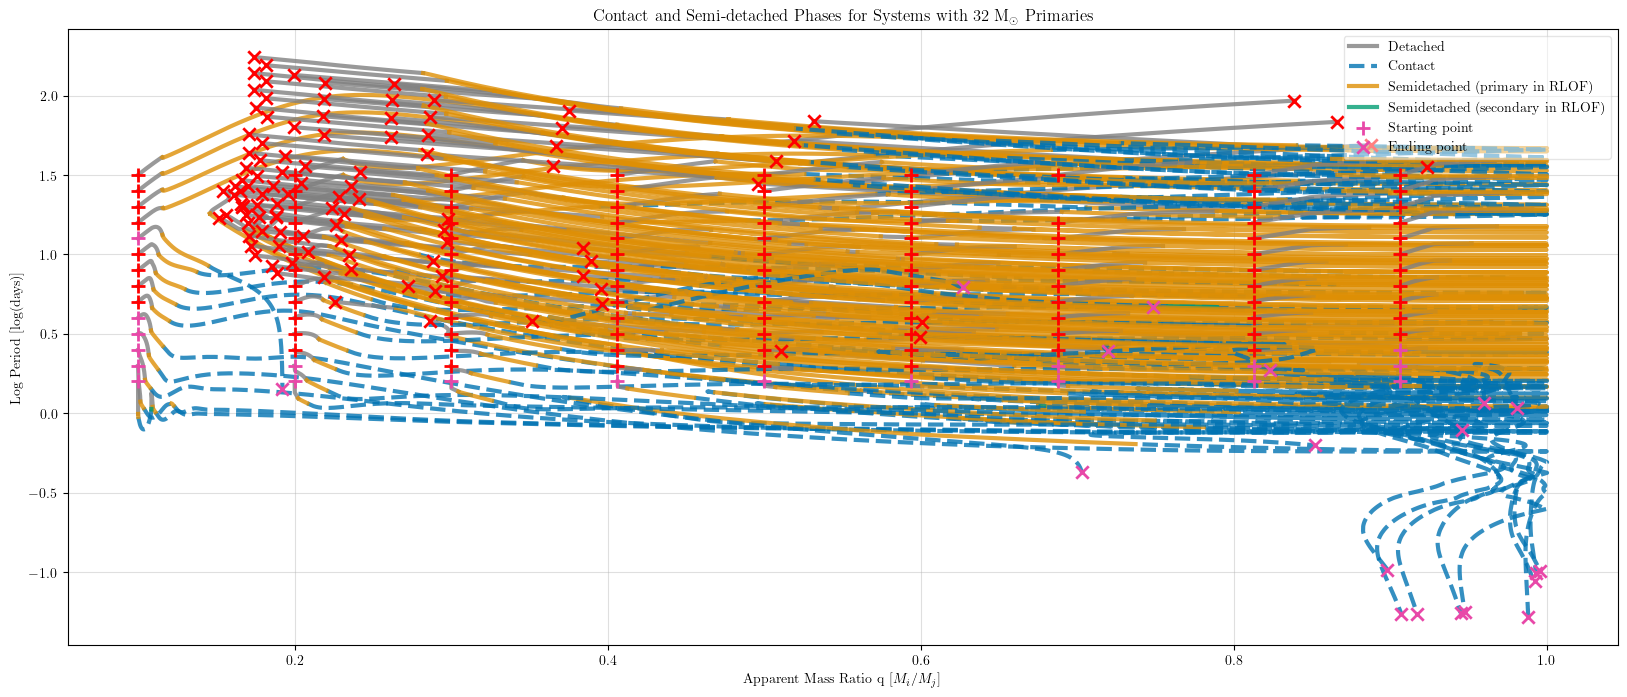

In [7]:
all_32M_sims = initial_32M_sims_dict.keys()
fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/32M_Grid'
plot_secondary_paths_on_period_MR_space(initial_32M_sims_dict, all_32M_sims, fig_path, fig_filename='Contact_semidettached_graph_apparent_32M.pdf', save_figure=True)

#### 20M Grid

In [8]:
filename = 'initial_20M_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    initial_20M_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(initial_20M_sims_dict))   # should be <class 'dict'>
print(initial_20M_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A20-0.1-0.2', 'A20-0.1-0.4', 'A20-0.1-0.5', 'A20-0.1-0.6', 'A20-0.1-0.7', 'A20-0.1-0.8', 'A20-0.1-0.9', 'A20-0.1-1.0', 'A20-0.1-1.1', 'A20-0.1-1.2', 'A20-0.1-1.3', 'A20-0.1-1.4', 'A20-0.1-1.5', 'A20-0.2-0.2', 'A20-0.2-0.3', 'A20-0.2-0.4', 'A20-0.2-0.5', 'A20-0.2-0.6', 'A20-0.2-0.7', 'A20-0.2-0.8', 'A20-0.2-0.9', 'A20-0.2-1.0', 'A20-0.2-1.1', 'A20-0.2-1.2', 'A20-0.2-1.3', 'A20-0.2-1.4', 'A20-0.2-1.5', 'A20-0.3-0.2', 'A20-0.3-0.3', 'A20-0.3-0.4', 'A20-0.3-0.5', 'A20-0.3-0.6', 'A20-0.3-0.7', 'A20-0.3-0.8', 'A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.2', 'A20-0.4-0.3', 'A20-0.4-0.4', 'A20-0.4-0.5', 'A20-0.4-0.6', 'A20-0.4-0.7', 'A20-0.4-0.8', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.2', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5-0.2', 'A20-0.5-0.3', 'A20-0.5-0.4', 'A20-0.5-0.5', 'A20-0.5-0.6', 'A20-0.5-0.7', 'A20-0.5-0.8', 'A20-0.5-0.9

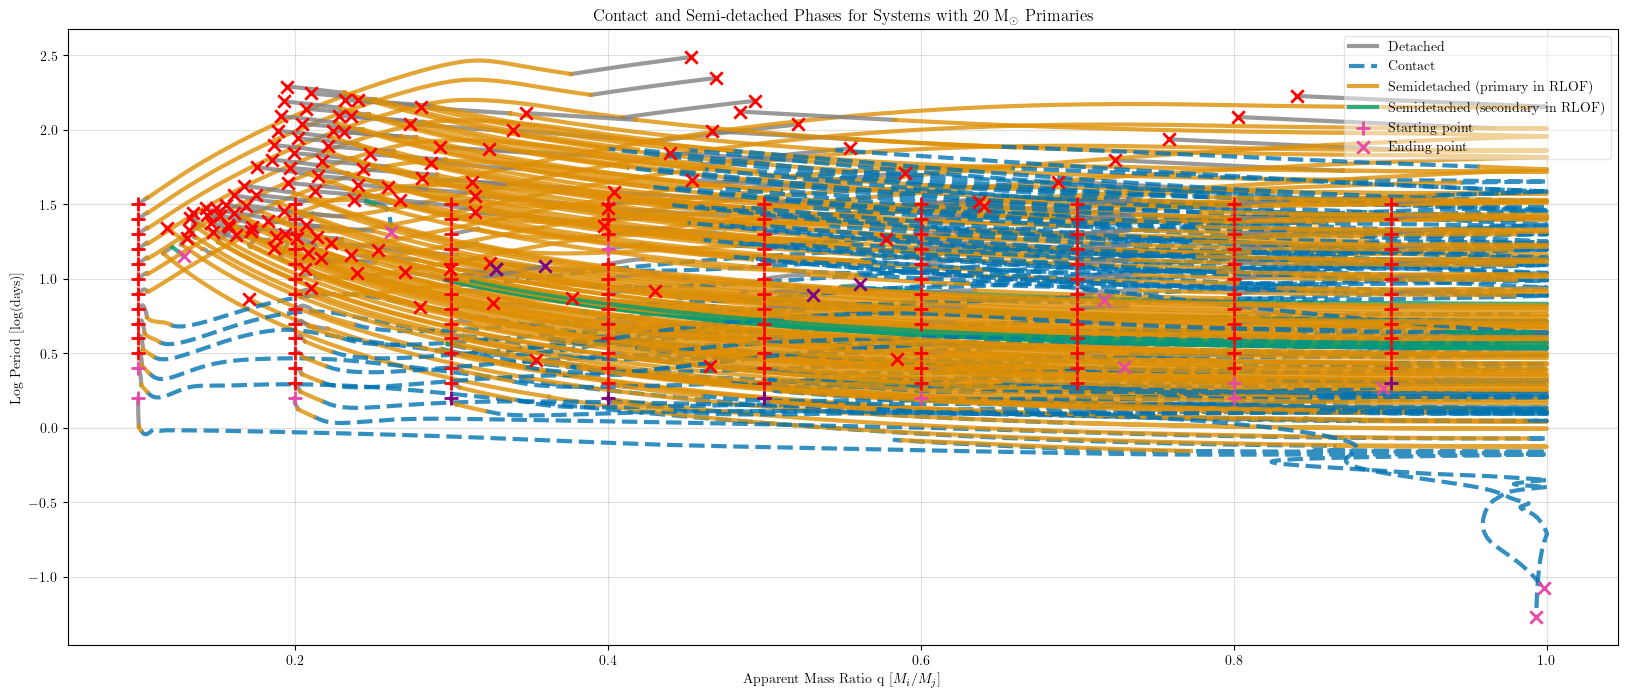

In [9]:
all_20M_sims = initial_20M_sims_dict.keys()
fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid'
plot_secondary_paths_on_period_MR_space(initial_20M_sims_dict, all_20M_sims, fig_path, fig_filename='Contact_semidettached_graph_apparent_20M.pdf', save_figure=True)

#### 20M Grid Complete

In [5]:
# import pickle

filename = 'complete_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    complete_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(complete_sims_dict))   # should be <class 'dict'>
print(complete_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A20-0.1-0.6', 'A20-0.1-0.7', 'A20-0.1-0.8', 'A20-0.1-0.9', 'A20-0.1-1.0', 'A20-0.1-1.1', 'A20-0.1-1.2', 'A20-0.1-1.3', 'A20-0.1-1.4', 'A20-0.1-1.5', 'A20-0.2-0.5', 'A20-0.2-0.6', 'A20-0.2-0.7', 'A20-0.2-0.8', 'A20-0.2-0.9', 'A20-0.2-1.0', 'A20-0.2-1.1', 'A20-0.2-1.2', 'A20-0.2-1.3', 'A20-0.2-1.4', 'A20-0.2-1.5', 'A20-0.3-0.2', 'A20-0.3-0.3', 'A20-0.3-0.4', 'A20-0.3-0.5', 'A20-0.3-0.6', 'A20-0.3-0.7', 'A20-0.3-0.8', 'A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.3', 'A20-0.4-0.4', 'A20-0.4-0.5', 'A20-0.4-0.6', 'A20-0.4-0.7', 'A20-0.4-0.8', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5-0.3', 'A20-0.5-0.4', 'A20-0.5-0.5', 'A20-0.5-0.6', 'A20-0.5-0.7', 'A20-0.5-0.8', 'A20-0.5-0.9', 'A20-0.5-1.1', 'A20-0.5-1.2', 'A20-0.5-1.3', 'A20-0.5-1.4', 'A20-0.6-0.3', 'A20-0.6-0.4', 'A20-0.6-0.5', 'A20-0.6-0.7', 'A20-0.6-0.9

In [25]:
sim_keys = complete_sims_dict.keys()

separate_sim_keys_rev = ['A20-0.3-0.2', 'A20-0.9-0.3']

separate_sim_keys_lower = []

mass_ratios = np.arange(0.1, 0.99, 0.1)
periods = np.arange(0.2, 0.85, 0.1)
for mass_ratio in mass_ratios:
    for period in periods:
        if f'A20-{mass_ratio:.1f}-{period:.1f}' in sim_keys and f'A20-{mass_ratio:.1f}-{period:.1f}' not in separate_sim_keys_rev:
            separate_sim_keys_lower.append(f'A20-{mass_ratio:.1f}-{period:.1f}')
# print(separate_sim_keys_lower)

separate_sim_keys_upper = []

mass_ratios = np.arange(0.1, 0.99, 0.1)
periods = np.arange(0.9, 1.55, 0.1)
for mass_ratio in mass_ratios:
    for period in periods:
        if f'A20-{mass_ratio:.1f}-{period:.1f}' in sim_keys and f'A20-{mass_ratio:.1f}-{period:.1f}' not in separate_sim_keys_rev:
            separate_sim_keys_upper.append(f'A20-{mass_ratio:.1f}-{period:.1f}')
print(separate_sim_keys_upper)

separate_sim_keys_upper_right = []

mass_ratios = np.arange(0.3, 0.99, 0.1)
periods = np.arange(0.9, 1.55, 0.1)
for mass_ratio in mass_ratios:
    for period in periods:
        if f'A20-{mass_ratio:.1f}-{period:.1f}' in sim_keys and f'A20-{mass_ratio:.1f}-{period:.1f}' not in separate_sim_keys_rev:
            separate_sim_keys_upper_right.append(f'A20-{mass_ratio:.1f}-{period:.1f}')
print(separate_sim_keys_upper_right)

separate_sim_keys_upper_left = []

mass_ratios = np.arange(0.1, 0.25, 0.1)
periods = np.arange(0.9, 1.55, 0.1)
for mass_ratio in mass_ratios:
    for period in periods:
        if f'A20-{mass_ratio:.1f}-{period:.1f}' in sim_keys and f'A20-{mass_ratio:.1f}-{period:.1f}' not in separate_sim_keys_rev:
            separate_sim_keys_upper_left.append(f'A20-{mass_ratio:.1f}-{period:.1f}')
print(separate_sim_keys_upper_left)

['A20-0.1-0.9', 'A20-0.1-1.0', 'A20-0.1-1.1', 'A20-0.1-1.2', 'A20-0.1-1.3', 'A20-0.1-1.4', 'A20-0.1-1.5', 'A20-0.2-0.9', 'A20-0.2-1.0', 'A20-0.2-1.1', 'A20-0.2-1.2', 'A20-0.2-1.3', 'A20-0.2-1.4', 'A20-0.2-1.5', 'A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5-0.9', 'A20-0.5-1.1', 'A20-0.5-1.2', 'A20-0.5-1.3', 'A20-0.5-1.4', 'A20-0.6-0.9', 'A20-0.6-1.0', 'A20-0.6-1.1', 'A20-0.6-1.2', 'A20-0.6-1.3', 'A20-0.6-1.4', 'A20-0.6-1.5', 'A20-0.7-1.1', 'A20-0.7-1.3', 'A20-0.7-1.4', 'A20-0.7-1.5', 'A20-0.8-1.2', 'A20-0.8-1.3', 'A20-0.8-1.5', 'A20-0.9-0.9', 'A20-0.9-1.0', 'A20-0.9-1.1', 'A20-0.9-1.2', 'A20-0.9-1.3', 'A20-0.9-1.4', 'A20-0.9-1.5']
['A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5

### Contact bin graph

In [5]:
filename = 'initial_20M_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    initial_20M_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(initial_20M_sims_dict))   # should be <class 'dict'>
print(initial_20M_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A20-0.1-0.2', 'A20-0.1-0.4', 'A20-0.1-0.5', 'A20-0.1-0.6', 'A20-0.1-0.7', 'A20-0.1-0.8', 'A20-0.1-0.9', 'A20-0.1-1.0', 'A20-0.1-1.1', 'A20-0.1-1.2', 'A20-0.1-1.3', 'A20-0.1-1.4', 'A20-0.1-1.5', 'A20-0.2-0.2', 'A20-0.2-0.3', 'A20-0.2-0.4', 'A20-0.2-0.5', 'A20-0.2-0.6', 'A20-0.2-0.7', 'A20-0.2-0.8', 'A20-0.2-0.9', 'A20-0.2-1.0', 'A20-0.2-1.1', 'A20-0.2-1.2', 'A20-0.2-1.3', 'A20-0.2-1.4', 'A20-0.2-1.5', 'A20-0.3-0.2', 'A20-0.3-0.3', 'A20-0.3-0.4', 'A20-0.3-0.5', 'A20-0.3-0.6', 'A20-0.3-0.7', 'A20-0.3-0.8', 'A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.2', 'A20-0.4-0.3', 'A20-0.4-0.4', 'A20-0.4-0.5', 'A20-0.4-0.6', 'A20-0.4-0.7', 'A20-0.4-0.8', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.2', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5-0.2', 'A20-0.5-0.3', 'A20-0.5-0.4', 'A20-0.5-0.5', 'A20-0.5-0.6', 'A20-0.5-0.7', 'A20-0.5-0.8', 'A20-0.5-0.9

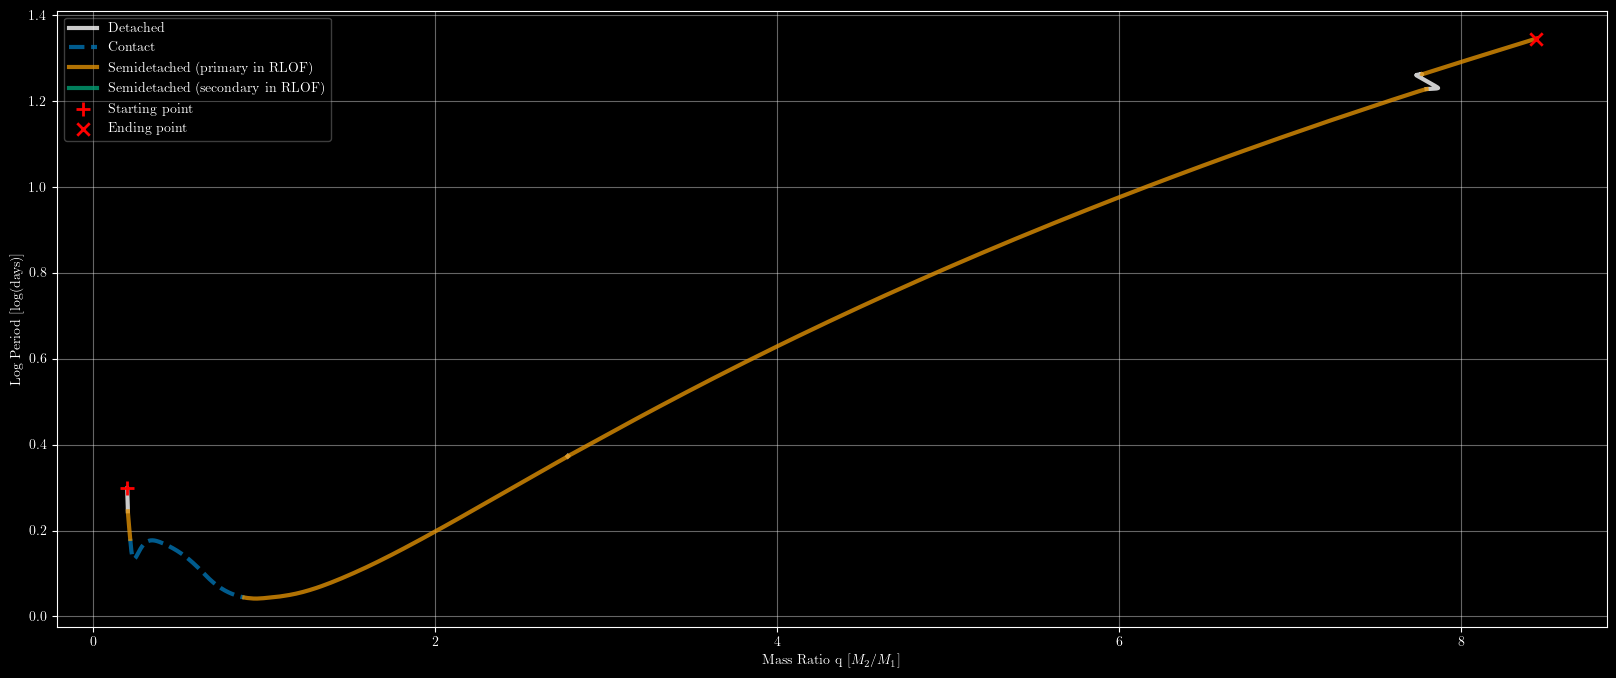

In [17]:
sim_key = 'A20-0.2-0.3'

star1 = initial_20M_sims_dict[sim_key]['star1']
star2 = initial_20M_sims_dict[sim_key]['star2']

Prim_mass = star1.iloc[0,5]

# Extract important information
binarysep = star1[36] #Binary Separation
radius1 = 10**star1[2] # Star radii
radius2 = 10**star2[2]
dM1 = star1[5]
dM2 = star2[5]
log_P = np.log10(star1[35])

# Calculate Roche radii
q_inv = dM1/dM2 #The mass ratio
q = dM2/dM1
roche1 = binarysep * ((0.49 * q_inv**(2/3)) / (0.6 * q_inv**(2/3) + np.log(1 + q_inv**(1/3)))) #Effective Roche Lobe
roche2 = binarysep * ((0.49 * q**(2/3)) / (0.6 * q**(2/3) + np.log(1 + q**(1/3))))

# Check if roche lobes are filled
rlof1 = radius1 - roche1
rlof1_mask = rlof1 >= 0
rlof2 = radius2 - roche2
rlof2_mask = rlof2 >= 0

# Create masks for contact and overflow phases
contact_phase_mask = rlof1_mask * rlof2_mask

overflow_occurs_mask = rlof1_mask ^ rlof2_mask
overflow_only_star1_mask = overflow_occurs_mask & rlof1_mask
overflow_only_star2_mask = overflow_occurs_mask & rlof2_mask

combined_mask = contact_phase_mask | overflow_only_star1_mask | overflow_only_star2_mask
no_overflow_mask = ~combined_mask


q_array = np.array(q, dtype=float)
log_P_array = np.array(log_P, dtype=float)

q_detached = q_array.copy()
q_detached[~no_overflow_mask] = np.nan

q_contact = q_array.copy()
q_contact[~contact_phase_mask] = np.nan

q_rlof1 = q_array.copy()
q_rlof1[~overflow_only_star1_mask] = np.nan

q_rlof2 = q_array.copy()
q_rlof2[~overflow_only_star2_mask] = np.nan

log_P_detached = log_P_array.copy()
log_P_detached[~no_overflow_mask] = np.nan

log_P_contact = log_P_array.copy()
log_P_contact[~contact_phase_mask] = np.nan

log_P_rlof1 = log_P_array.copy()
log_P_rlof1[~overflow_only_star1_mask] = np.nan

log_P_rlof2 = log_P_array.copy()
log_P_rlof2[~overflow_only_star2_mask] = np.nan
    

#Make plot
plt.figure(figsize=(20,8))
muted_colors = sns.color_palette("muted")
cb_colors = sns.color_palette("colorblind")

plt.plot(q_detached, log_P_detached, c='w', label='Detached', lw=3, alpha=0.8)
plt.plot(q_contact, log_P_contact, label='Contact', linestyle='--', c=cb_colors[0], lw=3, alpha=0.8)
plt.plot(q_rlof1, log_P_rlof1, label='Semidetached (primary in RLOF)', c=cb_colors[1], lw=3, alpha=0.8)
plt.plot(q_rlof2, log_P_rlof2, label='Semidetached (secondary in RLOF)', c=cb_colors[2], lw=3, alpha=0.8)


plt.scatter(q_array[0], log_P_array[0], marker='+', s=100, c='red', label='Starting point', zorder=5, lw=2)
plt.scatter(q_array[-1], log_P_array[-1], marker='x', s=80, c='red', label='Ending point', zorder=5, lw=2)

plt.xlabel(r'Mass Ratio q [$M_2$/$M_1$]')
plt.ylabel('Log Period [log(days)]')
plt.grid(alpha=0.4)
plt.legend(framealpha=0.3)
# plt.title()
plt.show()

In [34]:
def plot_2d_hist(q_vals, logP_vals, stage_name, color_map='mako', dq=0.05, dlogP=0.05):
    """Create a 2D histogram with fixed bin size in q and logP."""
    mask = ~np.isnan(q_vals) & ~np.isnan(logP_vals)
    q_vals, logP_vals = q_vals[mask], logP_vals[mask]
    
    # Define bin edges based on desired bin widths
    q_min, q_max = np.nanmin(q_vals), np.nanmax(q_vals)
    logP_min, logP_max = np.nanmin(logP_vals), np.nanmax(logP_vals)
    
    q_bins = np.arange(0, q_max + dq, dq)
    logP_bins = np.arange(0, logP_max + dlogP, dlogP)
    
    # Create 2D histogram
    plt.figure(figsize=(8, 6))
    h = plt.hist2d(q_vals, logP_vals, bins=[q_bins, logP_bins], cmap=color_map)
    
    plt.xlabel(r'Mass Ratio q [$M_2$/$M_1$]')
    plt.ylabel('Log Period [log(days)]')
    plt.title(f'{stage_name} Phase — Stacked {len(sim_keys_to_plot)} Sims')
    
    cbar = plt.colorbar(h[3])
    cbar.set_label('Counts per bin')
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [22]:
# Containers to collect all simulations’ data per stage
all_q_detached, all_logP_detached = [], []
all_q_contact, all_logP_contact = [], []
all_q_rlof1, all_logP_rlof1 = [], []
all_q_rlof2, all_logP_rlof2 = [], []

sim_keys_to_plot = initial_20M_sims_dict.keys()
simulation_dict = initial_20M_sims_dict



for sim_key in sim_keys_to_plot:
        # print(sim_key)
    
        # Check if system is reversed
        rev = simulation_dict[sim_key]['rev']
        merger = simulation_dict[sim_key]['merger']
        
        # Get out star1 and star2 plot data
        star1 = simulation_dict[sim_key]['star1']
        star2 = simulation_dict[sim_key]['star2']

        Prim_mass = star1.iloc[0,5]
        
        # # Get mass ratio
        # q_all = star2[5] / star1[5]
        # q = q_all[:len(star1[5])] # Cut the array to get rid of NaN values
        
        if rev:
            # print('Reversed')
            log_P = np.log10(star2[35])
            cross_colour = 'purple'
            plot_title = f'Contact and Semi-detached Phases for Reversed Systems with {Prim_mass:.0f} ' + r'M$_\odot$ Primaries'

        elif merger:
            # print('Reversed')
            log_P = np.log10(star1[35])
            cross_colour = 'pink'
            plot_title = f'Contact and Semi-detached Phases for Systems with {Prim_mass:.0f} ' + r'M$_\odot$ Primaries'
            
        else:
            log_P = np.log10(star1[35])
            cross_colour = 'red'
            plot_title = f'Contact and Semi-detached Phases for Systems with {Prim_mass:.0f} ' + r'M$_\odot$ Primaries'
    
    
        # Extract important information
        binarysep = star1[36] #Binary Separation
        radius1 = 10**star1[2] # Star radii
        radius2 = 10**star2[2]
        dM1 = star1[5]
        dM2 = star2[5]
    
        # Cut out extended simulation data
        binarysep = binarysep[:len(log_P)]
        radius1, radius2 = radius1[:len(log_P)], radius2[:len(log_P)]
        dM1, dM2 = dM1[:len(log_P)], dM2[:len(log_P)]
    
        # Calculate Roche radii
        q_inv = dM1/dM2 #The mass ratio
        q = dM2/dM1
        roche1 = binarysep * ((0.49 * q_inv**(2/3)) / (0.6 * q_inv**(2/3) + np.log(1 + q_inv**(1/3)))) #Effective Roche Lobe
        roche2 = binarysep * ((0.49 * q**(2/3)) / (0.6 * q**(2/3) + np.log(1 + q**(1/3))))
    
        # Check if roche lobes are filled
        rlof1 = radius1 - roche1
        rlof1_mask = rlof1 >= 0
        rlof2 = radius2 - roche2
        rlof2_mask = rlof2 >= 0
    
        # Create masks for contact and overflow phases
        contact_phase_mask = rlof1_mask * rlof2_mask
        
        overflow_occurs_mask = rlof1_mask ^ rlof2_mask
        overflow_only_star1_mask = overflow_occurs_mask & rlof1_mask
        overflow_only_star2_mask = overflow_occurs_mask & rlof2_mask
    
        combined_mask = contact_phase_mask | overflow_only_star1_mask | overflow_only_star2_mask
        no_overflow_mask = ~combined_mask
     
    
        q_array = np.array(q, dtype=float)
        log_P_array = np.array(log_P, dtype=float)
        
        q_detached = q_array.copy()
        q_detached[~no_overflow_mask] = np.nan
        
        q_contact = q_array.copy()
        q_contact[~contact_phase_mask] = np.nan
        
        q_rlof1 = q_array.copy()
        q_rlof1[~overflow_only_star1_mask] = np.nan
        
        q_rlof2 = q_array.copy()
        q_rlof2[~overflow_only_star2_mask] = np.nan
        
        log_P_detached = log_P_array.copy()
        log_P_detached[~no_overflow_mask] = np.nan
        
        log_P_contact = log_P_array.copy()
        log_P_contact[~contact_phase_mask] = np.nan
        
        log_P_rlof1 = log_P_array.copy()
        log_P_rlof1[~overflow_only_star1_mask] = np.nan
        
        log_P_rlof2 = log_P_array.copy()
        log_P_rlof2[~overflow_only_star2_mask] = np.nan


        # After computing q_detached, q_contact, etc...
        
        all_q_detached.append(q_detached)
        all_logP_detached.append(log_P_detached)
        
        all_q_contact.append(q_contact)
        all_logP_contact.append(log_P_contact)
        
        all_q_rlof1.append(q_rlof1)
        all_logP_rlof1.append(log_P_rlof1)
        
        all_q_rlof2.append(q_rlof2)
        all_logP_rlof2.append(log_P_rlof2)


# Flatten all the lists into single long arrays
all_q_detached = np.concatenate(all_q_detached)
all_logP_detached = np.concatenate(all_logP_detached)

all_q_contact = np.concatenate(all_q_contact)
all_logP_contact = np.concatenate(all_logP_contact)

all_q_rlof1 = np.concatenate(all_q_rlof1)
all_logP_rlof1 = np.concatenate(all_logP_rlof1)

all_q_rlof2 = np.concatenate(all_q_rlof2)
all_logP_rlof2 = np.concatenate(all_logP_rlof2)
            

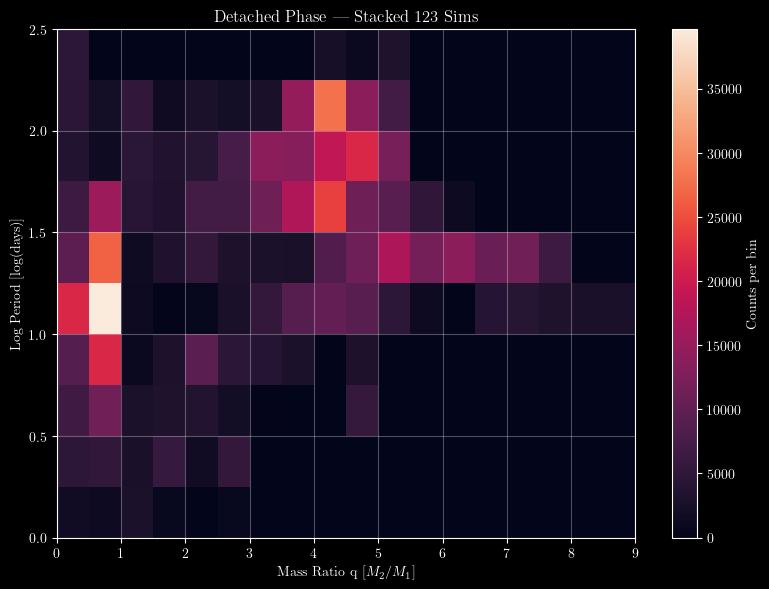

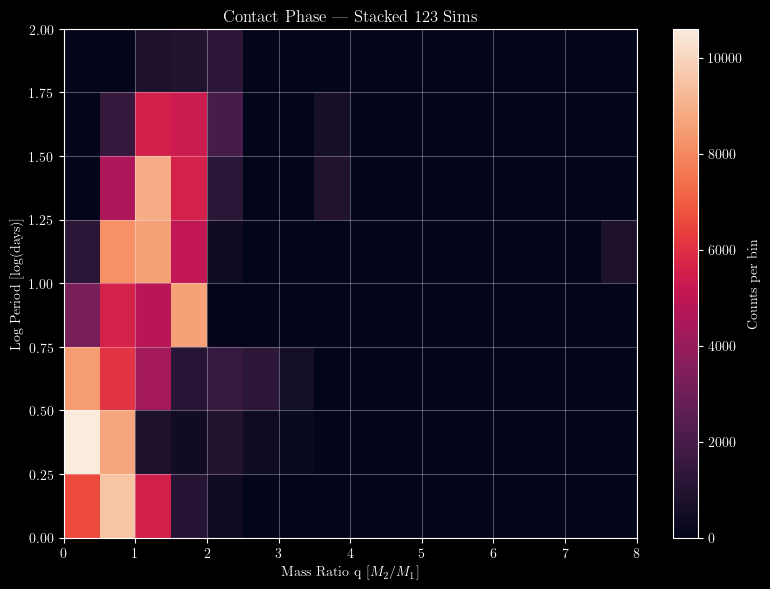

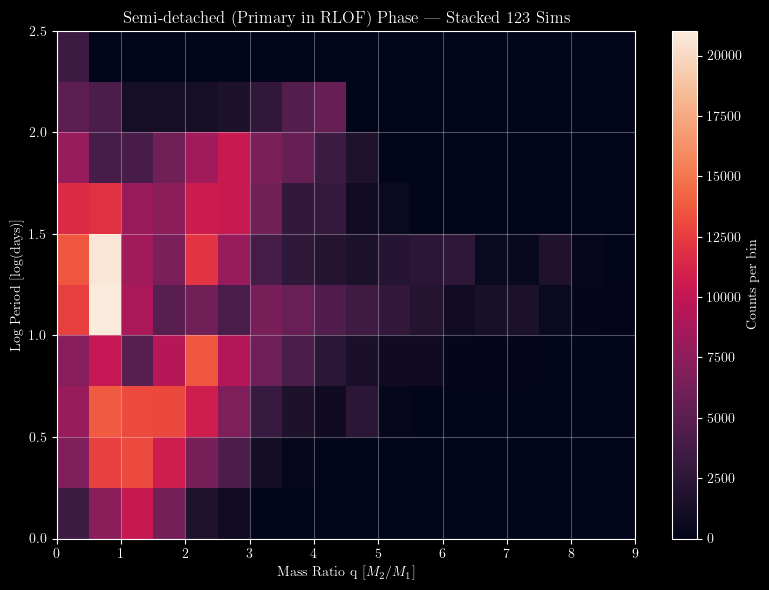

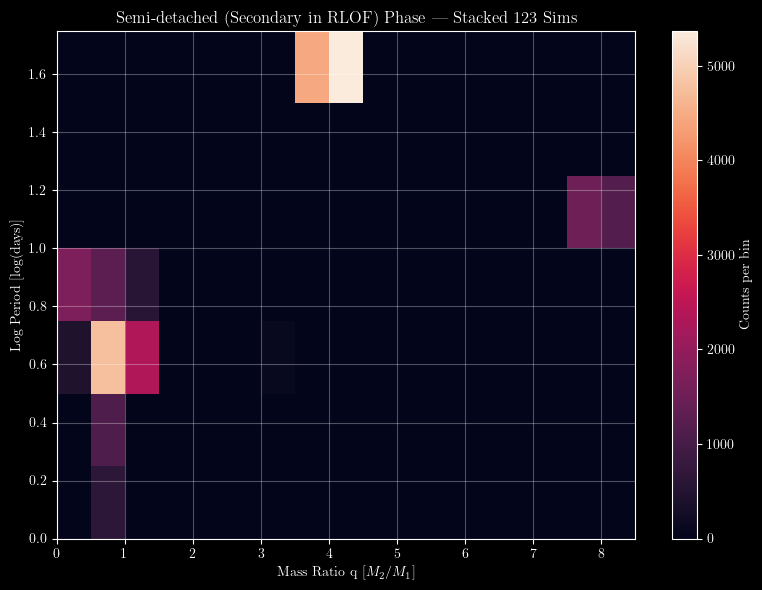

In [36]:
# plot_2d_hist(q_vals, logP_vals, stage_name, color_map='mako', dq=0.05, dlogP=0.05)

plot_2d_hist(all_q_detached, all_logP_detached, 'Detached', color_map='rocket', dq=0.5, dlogP=0.25)
plot_2d_hist(all_q_contact, all_logP_contact, 'Contact', color_map='rocket', dq=0.5, dlogP=0.25)
plot_2d_hist(all_q_rlof1, all_logP_rlof1, 'Semi-detached (Primary in RLOF)', color_map='rocket', dq=0.5, dlogP=0.25)
plot_2d_hist(all_q_rlof2, all_logP_rlof2, 'Semi-detached (Secondary in RLOF)', color_map='rocket', dq=0.5, dlogP=0.25)

### Multiple HR Diagrams

In [3]:
import pickle

filename = 'complete_sims_files.pkl'

# Load the dictionary
with open(filename, 'rb') as f:
    complete_sims_dict = pickle.load(f)

print("Dictionary successfully loaded!")
print(type(complete_sims_dict))   # should be <class 'dict'>
print(complete_sims_dict.keys())

Dictionary successfully loaded!
<class 'dict'>
dict_keys(['A20-0.1-0.6', 'A20-0.1-0.7', 'A20-0.1-0.8', 'A20-0.1-0.9', 'A20-0.1-1.0', 'A20-0.1-1.1', 'A20-0.1-1.2', 'A20-0.1-1.3', 'A20-0.1-1.4', 'A20-0.1-1.5', 'A20-0.2-0.5', 'A20-0.2-0.6', 'A20-0.2-0.7', 'A20-0.2-0.8', 'A20-0.2-0.9', 'A20-0.2-1.0', 'A20-0.2-1.1', 'A20-0.2-1.2', 'A20-0.2-1.3', 'A20-0.2-1.4', 'A20-0.2-1.5', 'A20-0.3-0.2', 'A20-0.3-0.3', 'A20-0.3-0.4', 'A20-0.3-0.5', 'A20-0.3-0.6', 'A20-0.3-0.7', 'A20-0.3-0.8', 'A20-0.3-0.9', 'A20-0.3-1.0', 'A20-0.3-1.1', 'A20-0.3-1.2', 'A20-0.3-1.3', 'A20-0.3-1.4', 'A20-0.3-1.5', 'A20-0.4-0.3', 'A20-0.4-0.4', 'A20-0.4-0.5', 'A20-0.4-0.6', 'A20-0.4-0.7', 'A20-0.4-0.8', 'A20-0.4-0.9', 'A20-0.4-1.0', 'A20-0.4-1.1', 'A20-0.4-1.3', 'A20-0.4-1.4', 'A20-0.4-1.5', 'A20-0.5-0.3', 'A20-0.5-0.4', 'A20-0.5-0.5', 'A20-0.5-0.6', 'A20-0.5-0.7', 'A20-0.5-0.8', 'A20-0.5-0.9', 'A20-0.5-1.1', 'A20-0.5-1.2', 'A20-0.5-1.3', 'A20-0.5-1.4', 'A20-0.6-0.3', 'A20-0.6-0.4', 'A20-0.6-0.5', 'A20-0.6-0.7', 'A20-0.6-0.9

In [4]:
dict_test = complete_sims_dict['A20-0.1-0.6']['star1']

print(dict_test)

          0             1        2        3        4         5        6   \
0          0  0.000000e+00  0.86513  4.48530  4.62470  20.00000  0.00001   
1          1  7.500000e+04  0.77132  4.53764  4.64642  19.99720  0.00002   
2          2  8.100000e+04  0.76754  4.53896  4.64417  19.99697  0.00002   
3          3  8.181005e+04  0.76738  4.53886  4.64343  19.99694  0.00002   
4          4  8.278211e+04  0.76680  4.53908  4.64318  19.99690  0.00002   
...      ...           ...      ...      ...      ...       ...      ...   
11618  11618  1.142314e+07  0.75862  4.58396  4.80634   3.27370  0.00000   
11619  11619  1.142314e+07  0.75871  4.58392  4.80635   3.27370  0.00000   
11620  11620  1.142315e+07  0.75878  4.58389  4.80636   3.27369  0.00000   
11621  11621  1.142315e+07  0.75885  4.58385  4.80636   3.27369  0.00000   
11622  11622  1.142315e+07  0.75893  4.58382  4.80637   3.27369  0.00000   

            7        8        9   ...   64   65   66   67   68   69        70  \
0     

Generated Programmatic Palette (Corrected):


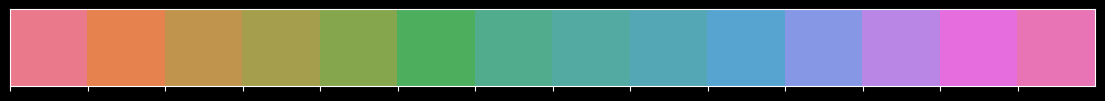

In [11]:
muted_rainbow = [
    '#e57373', '#d88c9a', '#f0b98d', '#e59866', '#f2d194', '#d9e4aa', 
    '#a3b18a', '#80bba3', '#5ca9a7', '#83b0d5', '#7d93b8', '#8e7cc3', 
    '#b0a4e3', '#c38d9e'
]

vibrant_rainbow = [
    '#f06262',  # Vibrant Red
    '#e07a8b',  # Deep Rose
    '#f2aa7d',  # Saturated Apricot
    '#e09351',  # Rich Terracotta
    '#f2cb7e',  # Golden Yellow
    '#c9d98f',  # Bright Lime
    '#9caf7c',  # Vivid Sage
    '#6ab8a0',  # Rich Seafoam
    '#4aa29f',  # Saturated Teal
    '#70a6d9',  # Bright Sky Blue
    '#6c88c1',  # Deep Cornflower
    '#8a6ac9',  # Vibrant Indigo
    '#a892f2',  # Bright Lavender
    '#c47995'   # Rich Mauve
]

n_colors = 14
programmatic_vibrant_palette = sns.husl_palette(
    n_colors=n_colors, 
    s=0.75,  # Saturation (0 to 1)
    l=0.65   # Lightness (0 to 1)
)

# --- You can quickly view the palette with sns.palplot ---
print("Generated Programmatic Palette (Corrected):")
sns.palplot(programmatic_vibrant_palette)
plt.show()


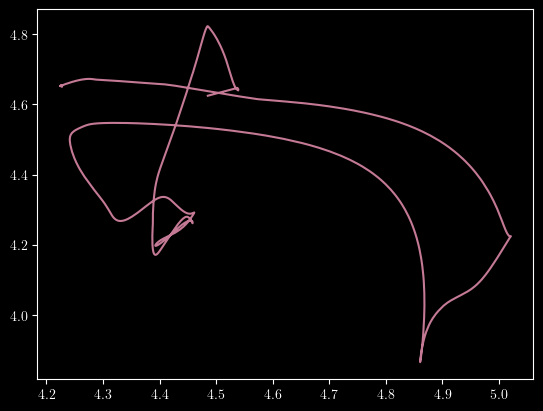

In [36]:
star1 = complete_sims_dict['A20-0.3-0.3']['star1']
log_Teff1, log_L1 = star1[3], star1[4]

plt.plot(log_Teff1, log_L1, c=vibrant_rainbow[i], label=f'log(P) = {period}')

Current MR: 0.1


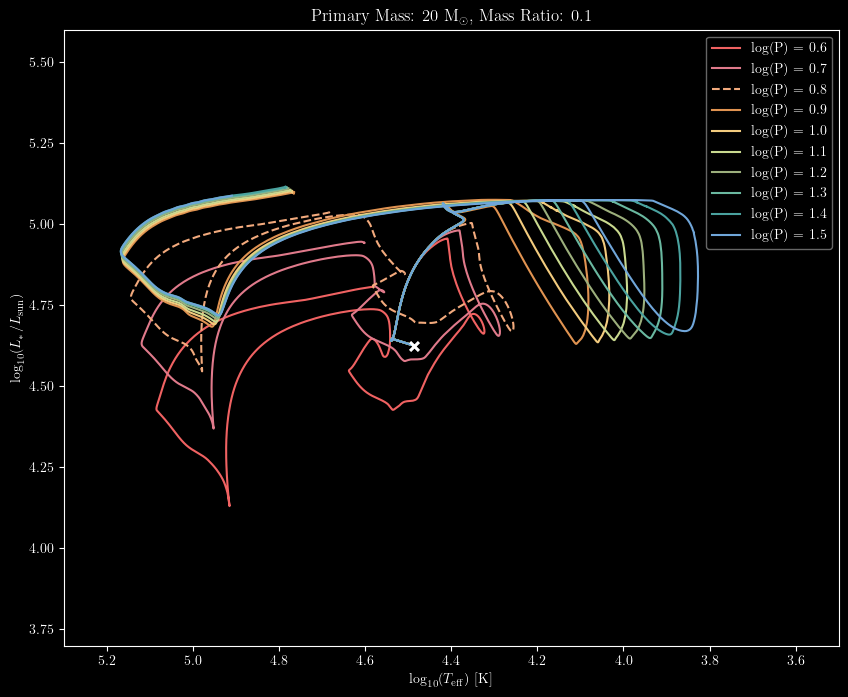

Current MR: 0.2


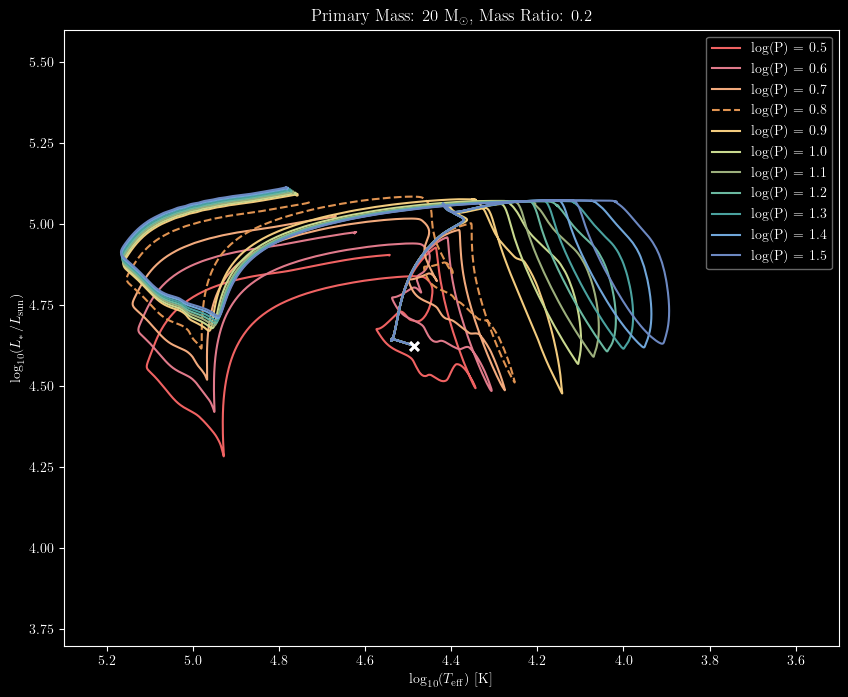

Current MR: 0.3


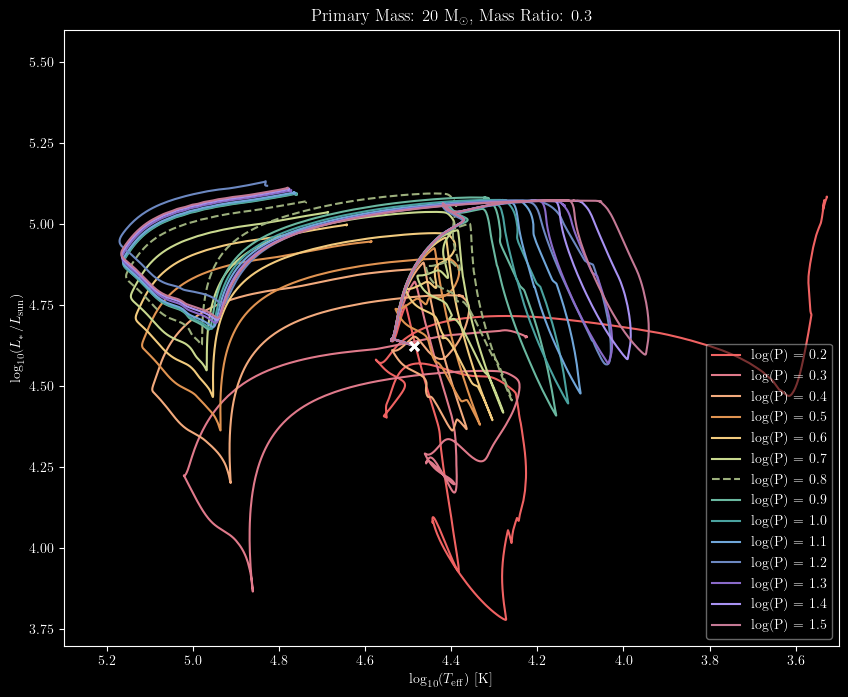

Current MR: 0.4


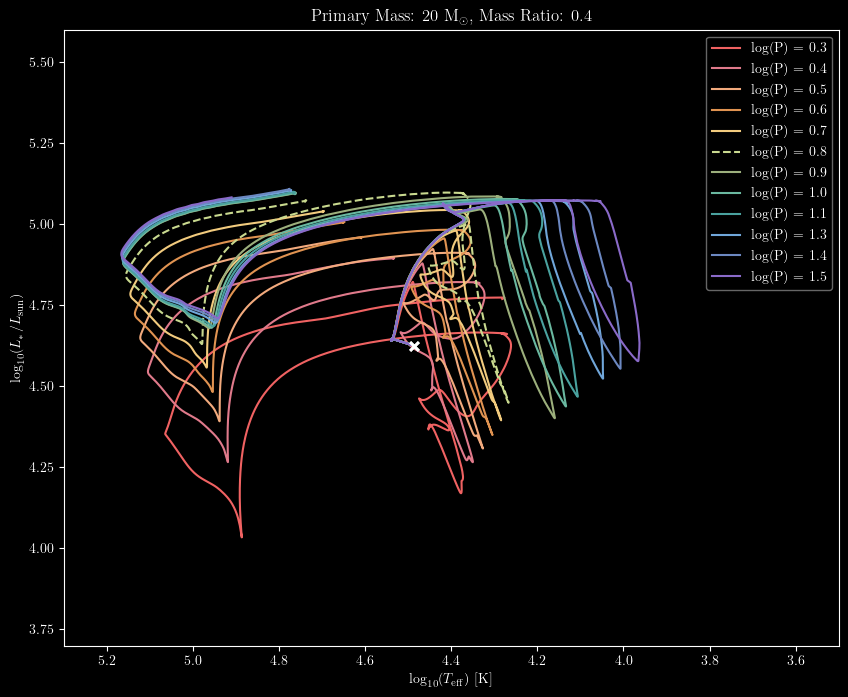

Current MR: 0.5


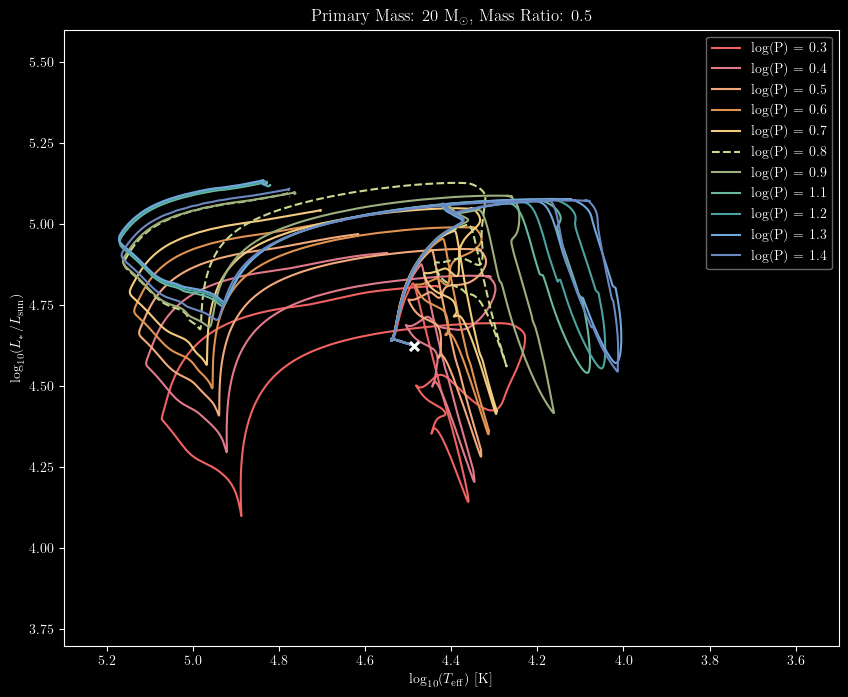

Current MR: 0.6


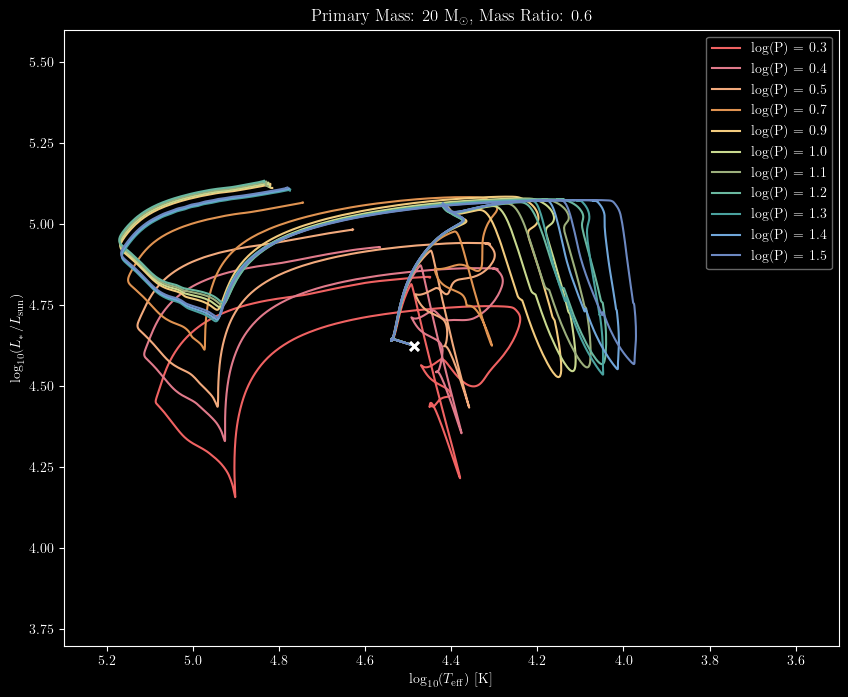

Current MR: 0.7


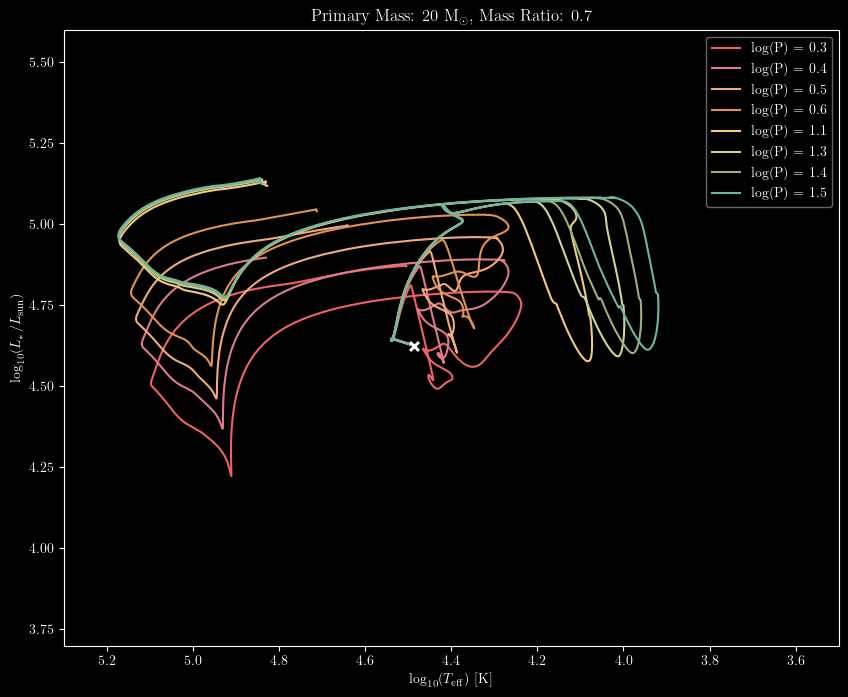

Current MR: 0.8


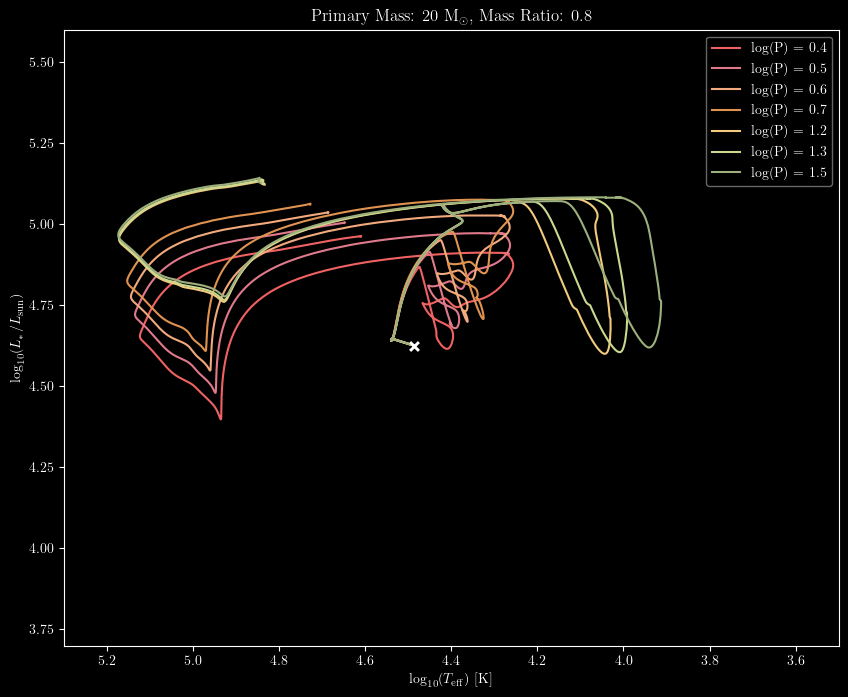

Current MR: 0.9


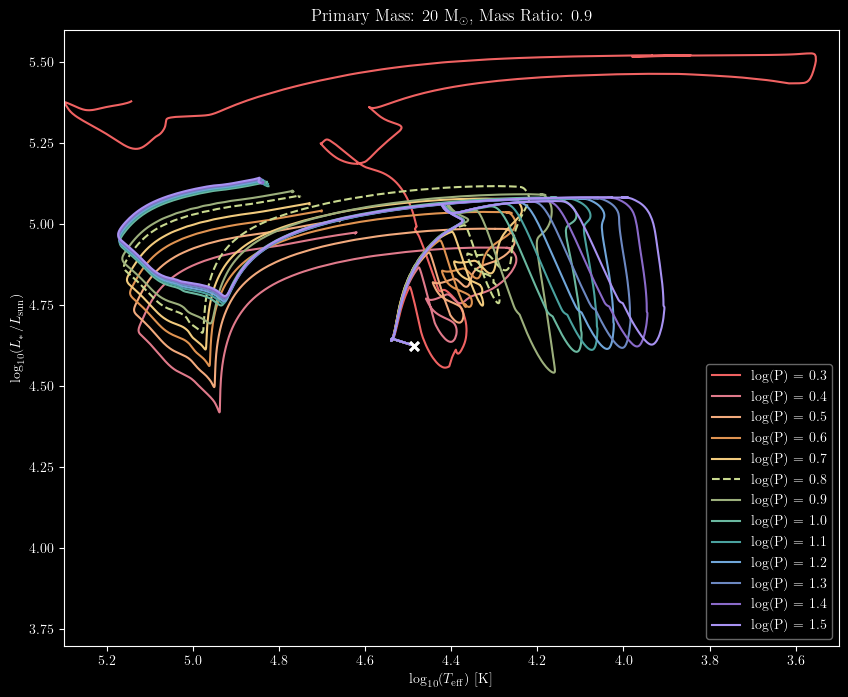

In [46]:
mass_ratios = np.arange(0.1, 0.95, 0.1)


for current_MR in mass_ratios:
    current_MR = round(current_MR, 1)
    title = r'Primary Mass: 20 M$_\odot$, ' + f'Mass Ratio: {current_MR}'
    i = 0

    plt.figure(figsize=(10,8))
    print('Current MR:', current_MR)
    for name in complete_sims_dict.keys():
        parts = name.split('-')
        mass_ratio = float(parts[1])
        period = float(parts[-1])

        if mass_ratio == current_MR:
            star1 = complete_sims_dict[name]['star1']

            
            log_Teff1, log_L1 = star1[3], star1[4]

            if period == 0.8:
                plt.plot(log_Teff1, log_L1, c=vibrant_rainbow[i], label=f'log(P) = {period}', linestyle='--')
            else:
                plt.plot(log_Teff1, log_L1, c=vibrant_rainbow[i], label=f'log(P) = {period}')
                
            plt.scatter(log_Teff1[0], log_L1[0], color='white', marker='x', zorder=3)
            i += 1


    plt.ylim(3.7, 5.6)
    plt.xlim(3.5, 5.3)
    plt.gca().invert_xaxis()
    plt.xlabel(r'$\log_{10}(T_{\text{eff}})$ [K]')
    plt.ylabel(r'$\log_{10}(L_*/L_{\text{sun}})$')
    plt.title(title)
    plt.legend(framealpha=0.5)
    plt.savefig(f'/home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid_Complete/HR_diagrams/{current_MR}_MR_HR.pdf', dpi=250, bbox_inches='tight')
    plt.show()
            
        

### He Plots

#### Helium mass:

Scanning simulation folders in: /home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid_Complete


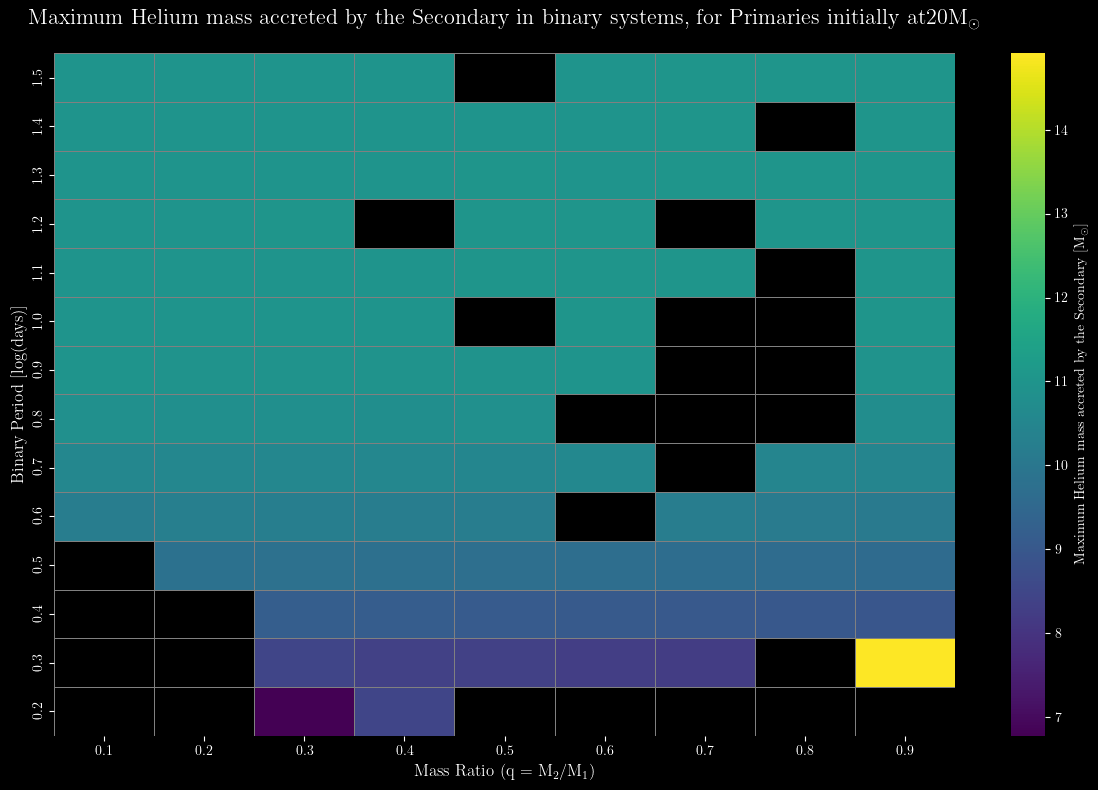

Figure saved to: /home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid_Complete/He_max_Secondary_mass.pdf
Grid completed!


In [3]:
#============================================================================================================================
# Maximum Mass Grid
#============================================================================================================================
# fig_path = 'C:/Users/micae/OneDrive/Documents/MASTERS/Figures/20M_Grid'
fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid_Complete'
# create_max_mass_merger_grid(fig_path, fig_path, save_figure=True, star_type='Secondary', mass_type='He', flatten=False, log_scale=False, difference=False)
create_max_mass_grid(fig_path, fig_path, save_figure=True, star_type='Secondary', mass_type='He')

#### Helium surface abundance:

### Secondary Maximum Mass

Scanning simulation folders in: /home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid


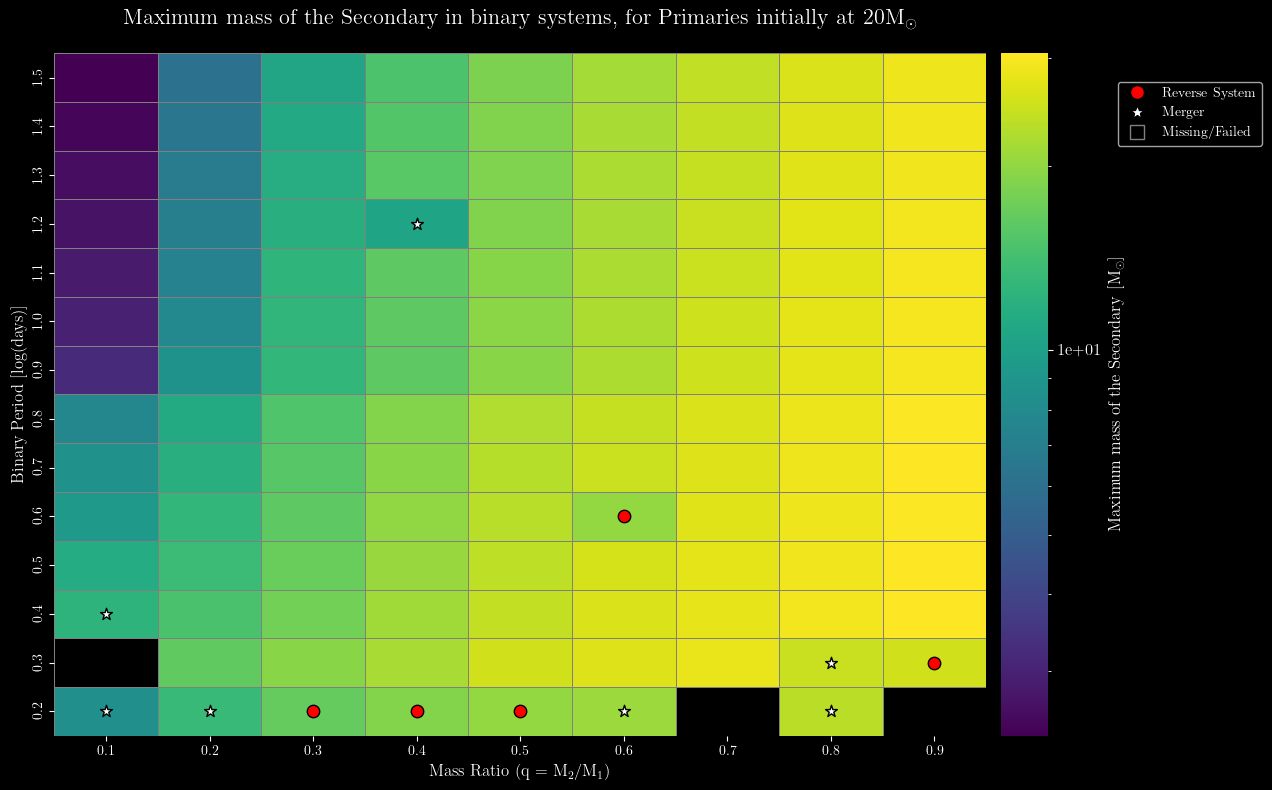

Figure saved to: /home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid/logscale_max_Secondary_mass.pdf
Grid completed!


In [8]:
#============================================================================================================================
# Maximum Mass Grid
#============================================================================================================================
# fig_path = 'C:/Users/micae/OneDrive/Documents/MASTERS/Figures/20M_Grid'
fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid'
# create_max_mass_grid(fig_path, fig_path, save_figure=True, star_type='Secondary')
create_max_mass_merger_grid(fig_path, fig_path, save_figure=True, star_type='Secondary', flatten=False, log_scale=True, difference=False)

Scanning simulation folders in: C:\Users\micae\OneDrive\Documents\MASTERS\Figures\20M_Grid


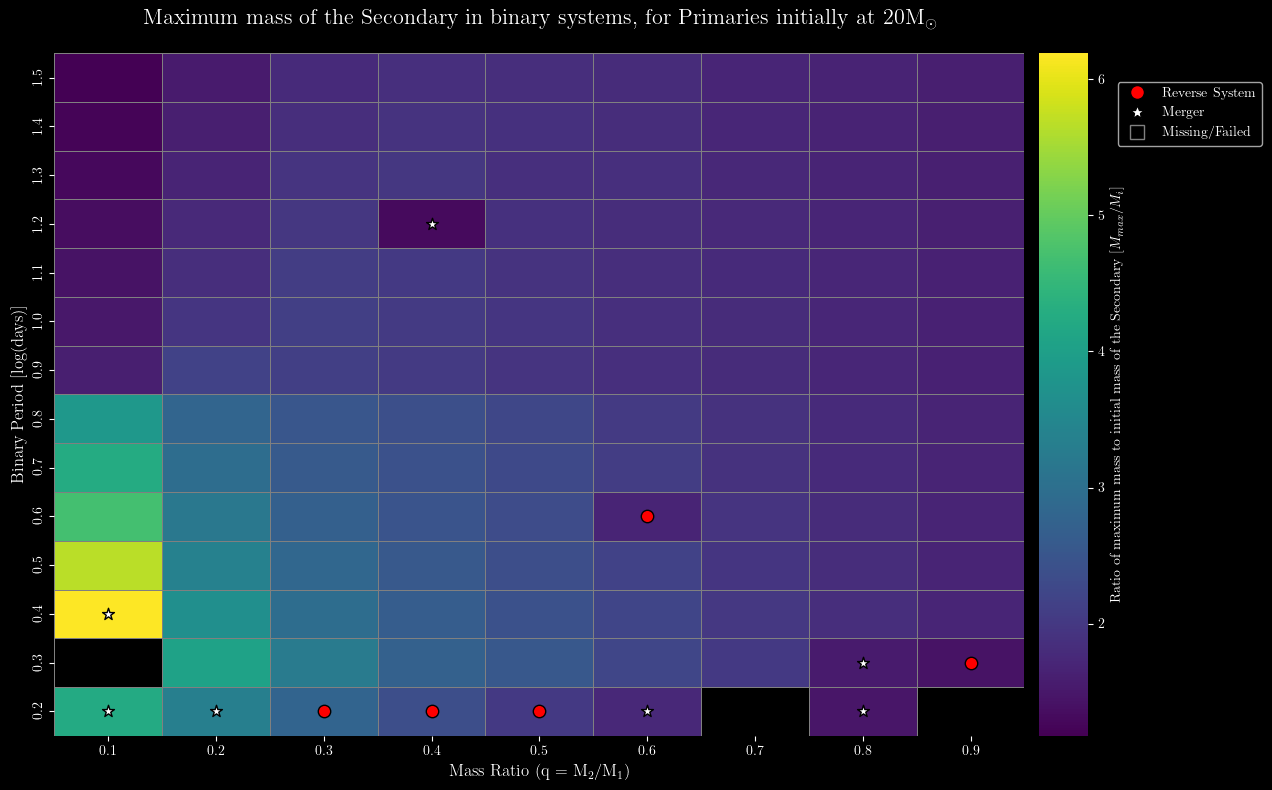

Grid completed!


In [3]:
#============================================================================================================================
# Maximum Mass Grid
#============================================================================================================================
fig_path = 'C:/Users/micae/OneDrive/Documents/MASTERS/Figures/20M_Grid'
# fig_path = '/home/micaelas/OneDrive/Documents/MASTERS/Figures/20M_Grid'
# create_max_mass_grid(fig_path, fig_path, save_figure=True, star_type='Secondary')
create_max_mass_merger_grid(fig_path, fig_path, save_figure=False, star_type='Secondary')

### Thermohaline

Scanning simulation folders in: C:\Users\micae\OneDrive\Documents\MASTERS\Figures\20M_Grid_Complete


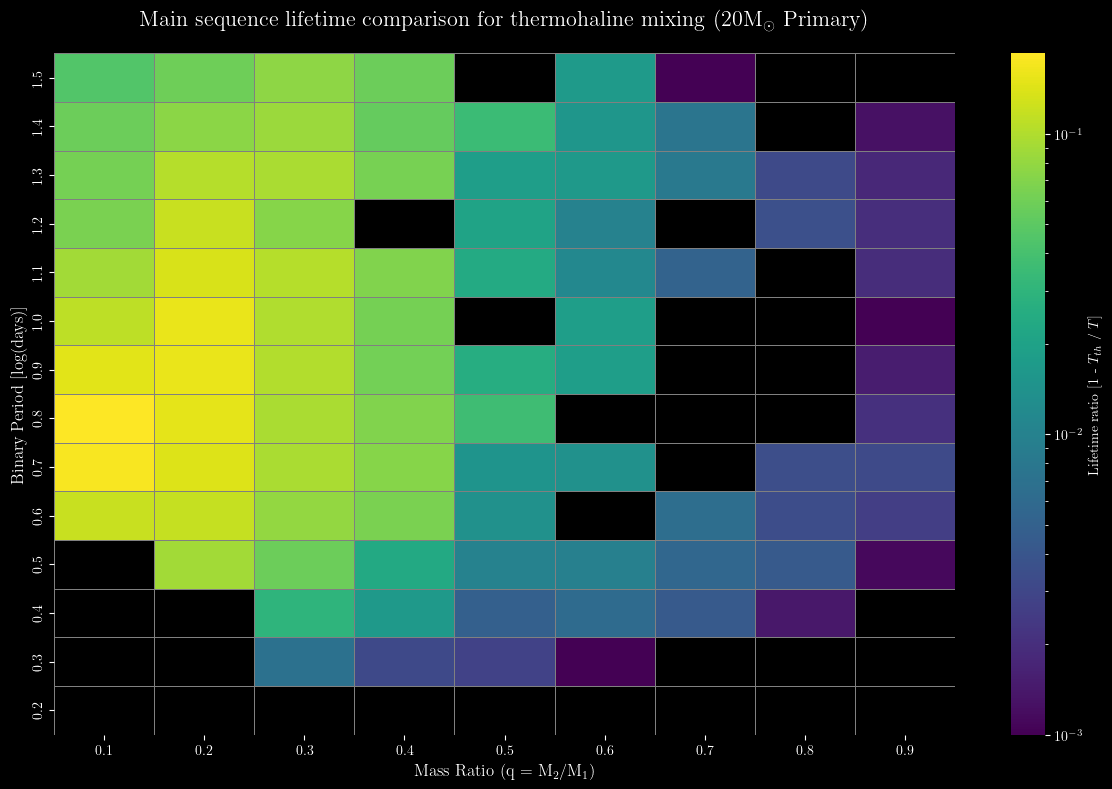

Figure saved to: C:\Users\micae\OneDrive\Documents\MASTERS\Figures\20M_Grid_Complete\thermohaline_lifetime_grid.pdf
Grid completed!


In [3]:
#============================================================================================================================
# Create thermohaline lifetime grid
#============================================================================================================================
fig_path = 'C:/Users/micae/OneDrive/Documents/MASTERS/Figures/20M_Grid_Complete'
thermohaline_lifetime_comparison_grid(path=fig_path, savepath=fig_path, save_figure=True)

### Mass loss rates

In [2]:
def get_out_models(file_path, lines_after=199):
    """
    Returns lists of output blocks from the STARS code out file.
    
    This function searches for two different key phrases and captures the lines
    that follow them. It correctly handles cases where one key phrase appears
    while the program is counting lines for another.
    
    Parameters:
    - file_path (str): Path to the specific file.
    - lines_after (int): Number of lines to include after a match for the first key phrase.
    
    Returns:
    - A tuple of three lists:
      - first_lot_matches (list): A list of strings, each being a full block matching the first phrase.
      - model_nums (list): A list of strings, each being a specific line captured after each 'first_lot' block.
      - second_lot_matches (list): A list of strings, each being a full block matching the second phrase.
    """
    first_lot_matches = []
    second_lot_matches = []
    model_nums = []
    
    collecting_state = 'none'
    lines_to_collect = 0
    extra_line_count = 0
    temp_buffer = []

    phrases1 = ['H1        He4        C12        N14']
    phrases2 = ['kappa      grada      gr-ga        m']

    with open(file_path, 'r', encoding='utf-8') as out:
        for line in out:

            if extra_line_count > 0:
                extra_line_count -= 1
                if extra_line_count == 0:
                    model_nums.append(line.strip())

            # --- Logic Part 2: Handle active block collection ---
            if collecting_state == 'first':
                temp_buffer.append(line)
                lines_to_collect -= 1
                if lines_to_collect == 0:
                    first_lot_matches.append("".join(temp_buffer))
                    collecting_state = 'none'
                    extra_line_count = 241
                continue

            elif collecting_state == 'second':
                temp_buffer.append(line)
                lines_to_collect -= 1
                if lines_to_collect == 0:
                    second_lot_matches.append("".join(temp_buffer))
                    collecting_state = 'none'
                continue
                
            if any(phrase in line for phrase in phrases1):
                temp_buffer = [line]
                lines_to_collect = lines_after
                collecting_state = 'first'
            elif any(phrase in line for phrase in phrases2):
                temp_buffer = [line]
                lines_to_collect = lines_after
                collecting_state = 'second'

    return first_lot_matches, second_lot_matches, model_nums




def convert_strings_to_plot_arrays(model_str_list, cols, model_num_strs=None):
    """
    Converts strings of models from out files into arrays for plotting.

    This function can optionally extract model numbers if they are provided.

    Parameters:
    - model_str_list (list): The list of model strings from get_out_models.
    - cols (list): A list of the names of the desired columns (e.g., ['log_T', 'log_R']).
    - model_num_strs (list, optional): The list of strings containing model numbers. 
                                       If None, this step is skipped. Defaults to None.

    Returns:
    - A tuple of two NumPy arrays: (plots, mod_nums)
      - plots: An array of shape (N, C, L) where N is the number of models,
               C is the number of columns, and L is the length of each column.
      - mod_nums: An array of the model numbers. Will be empty if model_num_strs is not provided.
    """
    plots = []
    mod_nums = []

    # Enumerate to get an index 'i' for accessing the corresponding model number string
    for i, model_string in enumerate(model_str_list):
        # --- Optional Step: Process model numbers ---
        # This block only runs if model_num_strs is provided
        if model_num_strs:
            try:
                # Use the corresponding model number string
                df_modnum = pd.read_csv(StringIO(model_num_strs[i]), sep=r"\s+", engine='python', header=None)
                modnum = df_modnum.iloc[0, 0]
                mod_nums.append(modnum)
            except (IndexError, pd.errors.EmptyDataError):
                # Handle cases where a model string might not have a matching number string
                print(f"Warning: Could not find or parse model number for model string index {i}. Appending NaN.")
                mod_nums.append(np.nan)

        # --- Core Step: Process the main model data ---
        # This part runs for every model string in the list
        df = pd.read_csv(StringIO(model_string), sep=r"\s+", engine='python')
        df = df.apply(pd.to_numeric, errors='coerce').fillna(0.0)

        final_cols = []
        for col in cols:
            # Check if the column exists to prevent errors
            if col in df.columns:
                vals = df[col].values
                final_cols.append(vals)
            else:
                print(f"Warning: Column '{col}' not found in model string index {i}. Appending empty array.")
                # Append an empty array or an array of zeros of the expected length
                # For simplicity, we'll note it here. A robust implementation might need a placeholder.
                pass
    
        plots.append(final_cols)
    
    # Convert lists to NumPy arrays for easier manipulation later
    plots = np.array(plots)
    mod_nums = np.array(mod_nums)
    
    return plots, mod_nums

In [4]:
path = '/media/micaelas/Expansion/Temp_sims/20M_Grid_ext/A20-0.1-0.5/out'
# path = 'E:/Temp_sims/20M_Grid_ext/A20-0.1-0.5/out'
first_lot_matches, second_lot_matches, model_nums = get_out_models(path, lines_after=199)


cols1 = ['n/n+1']
cols2 = ['grada']

plots1, mod_nums = convert_strings_to_plot_arrays(first_lot_matches, cols1, model_num_strs=model_nums)
plots2, _ = convert_strings_to_plot_arrays(second_lot_matches, cols2, model_num_strs=None)

In [5]:
print(plots1)
print(plots2)

[[[0.     1.093  0.6504 ... 0.7815 0.7905 0.7998]]

 [[0.     1.041  0.6519 ... 0.7875 0.7965 0.8048]]

 [[0.     0.9679 0.6542 ... 0.7905 0.7997 0.8079]]

 ...

 [[0.     0.6718 0.6718 ... 0.5675 0.4591 0.2673]]

 [[0.     0.6719 0.6718 ... 0.5675 0.4591 0.2675]]

 [[0.     0.6719 0.6718 ... 0.5674 0.4592 0.2676]]]
[[[0.3106 0.3105 0.3106 ... 0.2733 0.2729 0.2724]]

 [[0.3084 0.3083 0.3083 ... 0.2725 0.2721 0.2716]]

 [[0.3051 0.3051 0.3051 ... 0.2709 0.2705 0.27  ]]

 ...

 [[0.2855 0.2856 0.2856 ... 0.1888 0.2149 0.2536]]

 [[0.2855 0.2855 0.2856 ... 0.1888 0.2149 0.2535]]

 [[0.2855 0.2855 0.2856 ... 0.1888 0.2148 0.2534]]]


In [7]:
# dm/dt approx
path = '/media/micaelas/Expansion/Temp_sims/20M_grid/A20-0.1-0.5'
# path = 'E:/Temp_sims/20M_grid/A20-0.1-0.5'
file1, file2 = '/plot', '/plot2'
star1, star2 = readin_binary_data(path, file1, file2, single_star=False, print_summary=True)

This system initially has a 20.0M star and a 2.0M star, with an orbital period of 3.162 days. 



[-3.74666667e-08 -3.95833333e-08 -4.16666667e-08 ... -1.08618841e-05
 -1.08466329e-05 -1.06158104e-05]
[ 0.00000000e+00 -3.74666667e-08 -3.95833333e-08 ... -1.08618841e-05
 -1.08466329e-05 -1.06158104e-05]


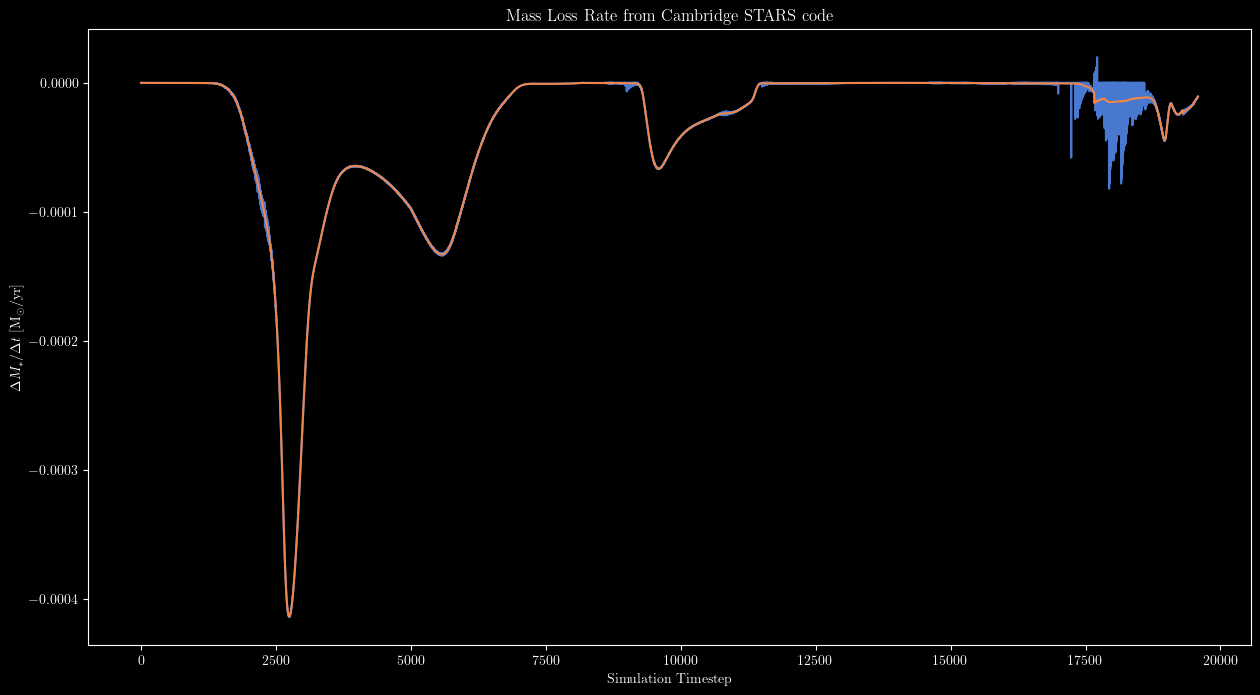

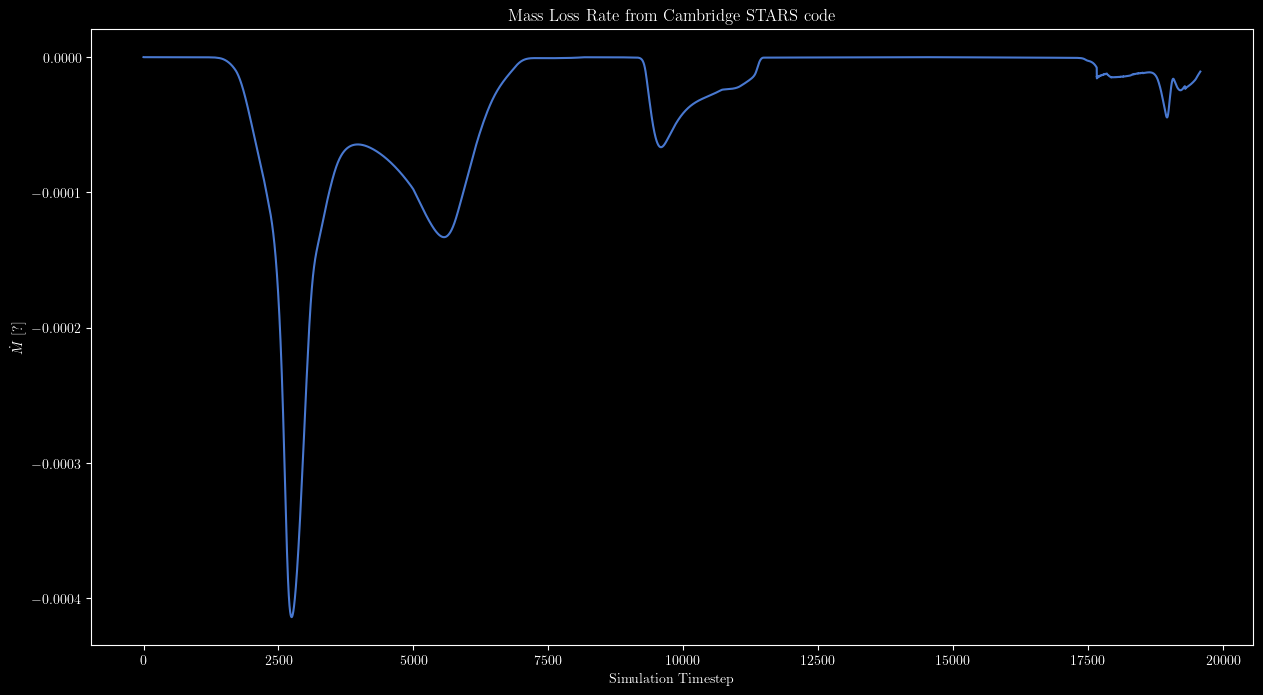

In [21]:
timestep = np.array(star1[0])
dm1 = np.diff(star1[5])
dt1 = np.array(star1.iloc[1:, 26])
mass_loss1 = dm1 / dt1
print(mass_loss1)
mass_loss1 = np.append([0], mass_loss1)
print(mass_loss1)

# print(timestep, len(timestep))
# print(dm1, len(dm1))
# print(dt1, len(dt1))
# print(mass_loss1, len(mass_loss1))

plt.figure(figsize=(15,8))
plt.plot(timestep, mass_loss1)
plt.plot(timestep, star1[45])
plt.title('Mass Loss Rate from Cambridge STARS code')
plt.xlabel('Simulation Timestep')
plt.ylabel(r'$\Delta M_*$/$\Delta t$ [M$_\odot$/yr]')
plt.show()

plt.figure(figsize=(15,8))
plt.plot(timestep, star1[45])
plt.title('Mass Loss Rate from Cambridge STARS code')
plt.xlabel('Simulation Timestep')
plt.ylabel(r'$\dot M$ [?]')
plt.show()

In [10]:
#Constants
pi = np.pi
e = np.exp(1)
G = 6.674e-11 #N·m²/kg²
Rg = 8.314 #J·mol⁻¹·K⁻¹

#I don't know yet
x_L = 10 # the x axis connects the two stars, x_L is the inner lagrangian point - we hsould be able to figure it out
mu_ph = 1 # mean molecular weight in photosphere (can use surface concentraations to figure out)
rho_ph = 1 #density of the photosphere
Phi_L = 1 #Potential at the lagrange point
Phi_ph = 1 #Potential at the photosphere
Hhat_p = 1 #photospheric scale pressure height / gamma(q) - look in Ritter BUT may not be needed??
integral = 1 #Can be done numerically 

In [14]:
#Solving the integral

#Make a plot of the function inside the integral, and use a solver

In [13]:
binarysep = star1[36]

radius1 = 10**star1[2]

dM1 = star1[5]
dM2 = star2[5]

M1 = dM1[0]
M2 = dM2[0]

q1 = dM1/dM2 #The mass ratio

roche1 = binarysep * ((0.49 * q1**(2/3)) / (0.6 * q1**(2/3) + np.log(1 + q1**(1/3)))) #Effective Roche Lobe

T_eff = 10**star1[3]


# Equaions for optically thin transfer (R<=R_R)
f1_q = roche1/binarysep # eq A5
g_q = q1/(x_L**3) + 1/((1-x_L)**3) # eq A4
F1_q = q1 * f1_q**(-3) * (g_q * (g_q - 1 - q1))**0.5 # eq A3
Mdot_0 = 2*pi/(e**0.5) * F1_q * (roche1**3/(G*M1)) * (Rg*T_eff / mu_ph)**(3/2) * rho_ph # eq A2

dPhi_small = (roche1 - radius1 / Hhat_p) * (Rg*T_eff / mu_ph) # eq A6 (for small dPhi)
dPhi_abs = Phi_L - Phi_ph # we will solve this properly

dPhi = dPhi_abs

Mdot_thin = Mdot_0 * np.exp(-(dPhi / (Rg*T_eff/mu_ph))) # eq A1

# Equations for optically thick transfer (R>R_R)
F3_Gamma1 = Gamma1**0.5 * (2/(Gamma1 + 1))**((Gamma1 + 1)/(2*(Gamma1 - 1))) # eq A18 (should be on the order of 1)

Mdot_thick = Mdot_0 + 2*pi*F1_q* (R_R**3 / (G *M1)) * integral

NameError: name 'Gamma1' is not defined

### Contact graphs

Scanning simulation folders in: C:\Users\micae\OneDrive\Documents\MASTERS\Figures\20M_Grid


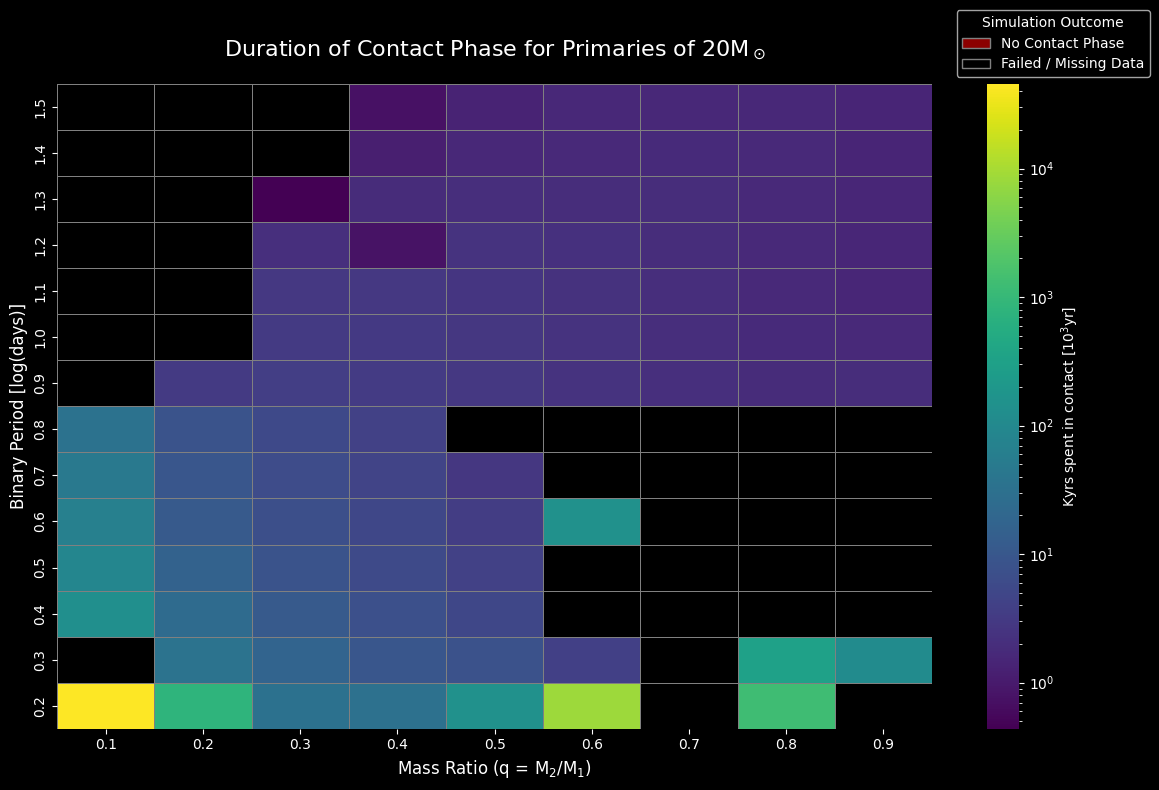

Figure saved to: C:\Users\micae\OneDrive\Documents\MASTERS\Figures\20M_Grid\contact_grid_kyr.pdf
Grid completed!


In [3]:
#============================================================================================================================
# Contact Binary Grid
#============================================================================================================================
fig_path = 'C:/Users/micae/OneDrive/Documents/MASTERS/Figures/20M_Grid'
create_contact_grid_kyr(fig_path, fig_path)

### Update incorrect timesteps and ages

In [26]:
import glob

def process_file(input_filepath, change_amount=100, age_change_amount=0, output_filepath=None):
    """
    Process a single file by adding/subtracting values to model number and age
    
    Args:
        input_filepath: Path to the input file
        change_amount: Amount to add to model number (first number, can be negative)
        age_change_amount: Amount to add to age in years (second number, can be negative)
        output_filepath: Path to the output file (if None, overwrites the input file)
    """
    if output_filepath is None:
        output_filepath = input_filepath
    
    lines = []
    first_line_processed = False
    
    # Read the file
    with open(input_filepath, 'r') as f:
        for line in f:
            # Skip empty lines
            if line.strip():
                # Split the line into parts (numbers)
                parts = line.split()
                
                if parts:  # If there are any parts
                    # Process model number (first number)
                    first_num = float(parts[0])
                    new_first_num = first_num + change_amount
                    
                    # Process age (second number) if it exists
                    if len(parts) > 1:
                        age = float(parts[1])
                        new_age = age + age_change_amount
                    
                    # Print info for first line only
                    if not first_line_processed:
                        print(f"First line: changing model number from {first_num} to {new_first_num}")
                        if len(parts) > 1:
                            print(f"First line: changing age from {age:.9E} to {new_age:.9E}")
                        first_line_processed = True
                    
                    # Format the model number appropriately
                    if new_first_num == int(new_first_num):
                        parts[0] = str(int(new_first_num))
                    else:
                        parts[0] = str(new_first_num)
                    
                    # Format the age in scientific notation if it exists
                    if len(parts) > 1:
                        parts[1] = f"{new_age:.9E}"
                    
                    # Rejoin the parts with appropriate spacing
                    new_line = '     ' + '  '.join(parts) + '\n'
                    lines.append(new_line)
            else:
                lines.append(line)
    
    # Write the modified content back
    with open(output_filepath, 'w') as f:
        f.writelines(lines)
    
    print(f"Processed: {input_filepath} -> {output_filepath}")
    print(f"  Model numbers changed by {change_amount:+g}")
    print(f"  Ages changed by {age_change_amount:+.9E}")

In [28]:
to_fix = ['A20-0.4-0.2', 'A20-0.4-1.2']

In [30]:
#============================================================================================================================
# Fixing timesteps and age for specific simulations
#============================================================================================================================
file1 = 'plot'
file2 = 'plot2'

for folder in to_fix:
    path = f'E:/Temp_sims/20M_grid/{folder}/' 
    # ext_path = f'E:/Temp_sims/20M_Grid_ext_combined/{folder}/' 
    final_ext_path = f'E:/Temp_sims/20M_Grid_ext_final_combined/{folder}/' 

    if not os.path.isdir(final_ext_path) or not os.path.isfile(os.path.join(final_ext_path, "plot")):
        continue

    star1, star2 = readin_binary_data(path, file1, file2, single_star=False, print_summary=True)

    res1, H1, He1, temp1, psi1 = get_final_out(star1, star2, path, final_ext_path, 'primary', save=False)
    res2, H2, He2, temp2, psi2 = get_final_out(star1, star2, path, final_ext_path, 'secondary', save=False)
    
    out_star1 = (res1, H1, He1, temp1, psi1)
    out_star2 = (res2, H2, He2, temp2, psi2)
    
    binary_res, data_to_write = determine_binary_result(out_star1, out_star2)
    
    if binary_res > 10:
        # System is reversed

        # Primary was the extended star
        lifetime1_1 = star1.iloc[-1,1]
        timestep1_1 = star1.iloc[-1,0]

        process_file(f'{final_ext_path}plot', -timestep1_1, -lifetime1_1)
        process_file(f'{final_ext_path}plot2', -timestep1_1, -lifetime1_1)
        
    else:
        # Standard system

        lifetime2_1 = star2.iloc[-1,1]
        timestep2_1 = star2.iloc[-1,0]

        process_file(f'{final_ext_path}plot', -timestep2_1, -lifetime2_1)
        process_file(f'{final_ext_path}plot2', -timestep2_1, -lifetime2_1)


    print(star2.iloc[-1,0])
    star_ext, star_ext_th = readin_binary_data(final_ext_path, file1, file2, single_star=False, print_summary=False)
    print(star_ext.iloc[0,0])

This system initially has a 20.0M star and a 8.0M star, with an orbital period of 1.585 days. 

First line: changing model number from 31180.0 to 18734.0
First line: changing age from 2.011995559E+07 to 2.640831610E+06
Processed: E:/Temp_sims/20M_Grid_ext_final_combined/A20-0.4-0.2/plot -> E:/Temp_sims/20M_Grid_ext_final_combined/A20-0.4-0.2/plot
  Model numbers changed by -12446
  Ages changed by -1.747912398E+07
First line: changing model number from 31180.0 to 18734.0
First line: changing age from 2.011995559E+07 to 2.640831610E+06
Processed: E:/Temp_sims/20M_Grid_ext_final_combined/A20-0.4-0.2/plot2 -> E:/Temp_sims/20M_Grid_ext_final_combined/A20-0.4-0.2/plot2
  Model numbers changed by -12446
  Ages changed by -1.747912398E+07
12446
18734
This system initially has a 20.0M star and a 8.0M star, with an orbital period of 15.85 days. 

First line: changing model number from 30780.0 to 27353.0
First line: changing age from 1.967739602E+07 to 1.086029833E+07
Processed: E:/Temp_sims/20M

### Completely thermohaline simulations

### Lifetimes

### Single graphs